**Lab2-DL: A1-CNN-intro.ipynb** (BMED365) | Priority: 1 (core)

_A brief introduction to CNNs for medical students – AI-assisted notebook_

[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab2-DL/notebooks/A1-CNN-intro.ipynb)

Last updated: 2025-12-21, 2026-01-15 A. Lundervold

Use the `bmed365-2026` conda environment or Google Colab




## Learning Objectives

By the end of this notebook, you will be able to:

| Objective | Description |
|-----------|-------------|
| **Understand CNN architecture** | Explain the purpose of convolutional, pooling, and fully connected layers |
| **Trace data flow** | Describe how a 28×28 image becomes a 10-class prediction |
| **Interpret convolution** | Explain what filters detect and why output size shrinks |
| **Read feature maps** | Understand what each layer "sees" in an image |
| **Connect to medicine** | Relate CNN concepts to medical image analysis |
| **Understand classification** | Explain logits, softmax, and probability interpretation |

---

## MNIST: Deep Learning's "Hello World"

### What is the MNIST problem?

**MNIST** (Modified National Institute of Standards and Technology) is a dataset of **70,000 handwritten digits** (0-9), where each digit is a 28×28 pixel grayscale image. The task is simple: given an image, classify which digit it shows.

<div style="text-align: center; margin: 20px 0;">

| Example | Task |
|:--------:|:--------|
| ![0](https://upload.wikimedia.org/wikipedia/commons/2/27/MnistExamples.png) | Classify each 28×28 image into one of 10 classes (digits 0-9) |

*Examples from the MNIST dataset. Source: Wikipedia*
</div>

### Historical significance

MNIST has played a crucial role in the development of deep learning:

| Year | Milestone | Significance |
|----|---------|-----------|
| **1998** | Yann LeCun introduces LeNet-5 | First successful CNN on MNIST (~99% accuracy) |
| **2006** | Geoffrey Hinton relaunches deep learning | MNIST becomes standard benchmark |
| **2012** | AlexNet wins ImageNet | CNN architectures from MNIST scale up |
| **Today** | State-of-the-art: 99.8%+ | MNIST is now considered "solved", but remains pedagogically valuable |

> **"MNIST is to machine learning what 'Hello World' is to programming"**  
> – Francois Chollet, creator of Keras

### Why MNIST for medical students?

MNIST illustrates the **core principles** used in medical image analysis:

| MNIST concept | Medical application |
|---------------|---------------------|
| Image classification | X-ray: normal vs. pathological |
| Feature extraction | Detecting lesions, tumors, fractures |
| Convolutional filters | Edge detection in histopathology |
| Probability output | Differential diagnosis with confidence level |

### PyTorch: Our tool

**PyTorch** is an open-source deep learning framework developed by Meta AI. We use it because:

- 🔬 **Research-friendly**: Used by most AI laboratories
- 🏥 **Medical AI**: Standard in MONAI, fastMONAI, and other medical AI libraries  
- 📚 **Pedagogical**: Clear and readable code that shows what happens "under the hood"
- ⚡ **GPU acceleration**: Trains models quickly (also works without GPU)

```
Data flow in this notebook:

    MNIST images (28×28)
           │
           ▼
    ┌─────────────┐
    │   PyTorch   │  ← Data loading, tensors, training
    │   + CNN     │  ← Convolution, pooling, classification
    └─────────────┘
           │
           ▼
    Predicted digit (0-9)
```

---

*Let's now set up the environment and explore the data!*


## Understanding CNNs: A Medical Perspective

![Deep Learning hierarchical feature extraction](../assets/Waldrop-multiple-hidden-layers.png)

*__Figure:__ Deep learning builds on hierarchical feature extraction. From left: input image → early layers detect simple patterns (edges, light/dark) → intermediate layers combine these into complex structures → output provides classification. (Source: M. Waldrop, PNAS 2019)*

**Key concept:** Just as your brain processes visual information through hierarchical layers (from retina to visual cortex), a CNN learns to recognize patterns from simple to complex - from pixels to diagnoses.

Let's explain this neural network architecture using analogies from medical imaging and diagnostics:

### Overview
Think of this CNN as a medical specialist examining an X-ray image or a histology slide, progressively identifying more complex patterns before making a diagnosis.

### Layer-by-layer explanation (medical context):

1. **Input layer (28x28 image)**
   - Like receiving a grayscale microscope image or a small X-ray section
   - Corresponds to what you see under low magnification
   - Size: 28x28 pixels, one channel (like a grayscale histology image)

2. **First convolutional layer (Conv1)**
   - Like your first look through the microscope
   - Detects 32 different basic patterns (like cell edges, simple shapes)
   - Like having 32 different stains each highlighting different basic features
   - Output: 26x26x32 (32 different "views" of the image)

3. **First pooling layer (Pool1)**
   - Like taking a step back to get a broader overview
   - Retains the most important features while reducing details
   - Corresponds to when you zoom out on the microscope to see patterns
   - Reduces size to 13x13, but retains all 32 feature types

4. **Second convolutional layer (Conv2)**
   - Like looking for more complex patterns
   - Now looking for 64 different combinations of the basic features
   - Corresponds to how you combine basic findings into more complex diagnoses
   - Example: combines cell shape AND arrangement patterns

5. **Second pooling layer (Pool2)**
   - Further consolidation of findings
   - Like taking another step back to see broader patterns
   - Reduces to 5x5 size, but retains 64 feature types

6. **First fully connected layer (FC1)**
   - Like the initial diagnostic reasoning
   - Combines all observed features (1600 inputs → 128 neurons)
   - Corresponds to how you integrate multiple findings into differential diagnoses

7. **Final layer (FC2)**
   - The final diagnosis
   - 10 possible outcomes (like 10 possible diagnoses)
   - Each output represents the probability for each diagnosis

### Medical analogy for the process:
1. **Initial examination** (Input → Conv1)
   - Like your first look at a patient or sample
   - Identifies basic features (edges, shapes, textures)

2. **Pattern recognition** (Pool1 → Conv2)
   - Corresponds to recognizing patterns in pathology
   - Combines basic features into meaningful patterns

3. **Integration** (Pool2 → FC1)
   - Like combining multiple clinical findings
   - Builds a complete clinical picture

4. **Diagnosis** (FC2)
   - Final diagnostic decision
   - Probability for each possible diagnosis

### Clinical relevance:
- Corresponds to how you go from basic observations to final diagnosis
- Mirrors the medical decision-making process:
  1. Observe basic features
  2. Recognize patterns
  3. Combine findings
  4. Make a diagnosis

This is analogous to how you might examine a histology slide, where you start with basic cellular features and progressively integrate information to reach a diagnosis.


## Understanding the CNN Architecture Visualization: A Medical Perspective

This code creates a visual representation of our neural network, similar to how we might draw an anatomical diagram or a clinical workflow. Let's explain it in medical terms:

### Overall structure
Think of this as creating an anatomical atlas or a clinical pathway diagram:

```python
class CNNVisualizer:
    def __init__(self):
        # Color scheme like different tissue stains or medical diagrams
        self.colors = {
            'input': '#e2e8f0',    # Light gray for raw image (like unstained tissue)
            'conv': '#93c5fd',     # Blue for feature detection (like H&E staining)
            'pool': '#bfdbfe',     # Light blue for summary (like low magnification)
            'fc': '#fca5a5',       # Red for decision-making (like diagnostic areas)
            'text': '#1e293b'      # Dark gray for labels
        }
```

### Layer representation
Similar to how we represent different anatomical structures or diagnostic steps:

```python
layers = [
    # Like progression through microscope magnifications
    {'name': 'Input\n28x28x1', 'type': 'input'},      # Raw sample
    {'name': 'Conv1\n26x26x32', 'type': 'conv'},      # Initial features (like cell boundaries)
    {'name': 'Pool1\n13x13x32', 'type': 'pool'},      # Broader patterns (like tissue architecture)
    {'name': 'Conv2\n11x11x64', 'type': 'conv'},      # Complex features (like cell arrangements)
    {'name': 'Pool2\n5x5x64', 'type': 'pool'},        # Overall patterns
    {'name': 'FC\n128->10', 'type': 'fc'}             # Final diagnosis
]
```

### Visual elements

1. **Blocks (rectangular areas)**
   - Like different stages in a clinical workflow
   - Size indicates complexity (wider blocks = more complex processing)
   - Colors distinguish between different types of analysis (like different staining techniques)

2. **Arrows**
   - Like clinical pathways showing progression
   - Similar to how we draw step-by-step diagnostic processes
   - Shows information flow from observation to diagnosis

3. **Text labels**
   - Like anatomical labels or diagnostic criteria
   - Shows dimensions and transformations at each step
   - Helps track the progression of the analysis

4. **Legend**
   - Similar to how we label different tissue types in histology
   - Explains the meaning of different colors
   - Helps interpret the diagram

### Medical analogy
This visualization represents a process similar to:
1. **Input layer**: Initial patient presentation/sample
2. **Convolutional layers**: Detailed examination (like using different microscope objectives)
3. **Pooling layers**: Taking a step back to see broader patterns (like switching to lower magnification)
4. **Fully connected layers**: Integration of findings and diagnostic decision-making

### Clinical relevance
- The diagram flows from left to right like a clinical pathway
- Different colors represent different types of analysis (like different diagnostic tools)
- The progression mirrors medical decision-making:
  1. Initial observation
  2. Detailed examination
  3. Pattern recognition
  4. Diagnostic conclusion

This visualization helps understand how the CNN processes information, just as we visualize clinical workflows or anatomical structures in medical education.


## Understanding Convolution: A Medical Analogy

### Overview
Think of convolution as using a specialized filter or stain to highlight specific features in a medical image – just as different staining techniques reveal different tissue properties.

### The three main components (like a staining process):

| Component | Description | Medical analogy |
|-----------|-------------|-----------------|
| **Input (original image)** | 5×5 grid of pixel values | Like your original tissue sample or X-ray |
| **Convolution kernel (filter)** | 3×3 pattern that functions as a "stain" | Like choosing the right stain for the desired structure |
| **Output (result)** | Shows where the pattern was detected | Like the finished stained image |

### The process (like a staining protocol):

1. **Select window** – Take a 3×3 section (like focusing the microscope on an area)
2. **Pattern matching** – Multiply pixel values by kernel values (like dye uptake in tissue)
3. **Summarization** – Sum all products into one value (like measuring stain intensity)
4. **Move window** – Repeat for the entire image

### Clinical relevance
The convolution kernel is like choosing the right stain:
- **H&E** for general structure
- **Special stains** for specific components  
- **Immunostaining** for specific proteins

This visualization shows how CNNs can automatically detect patterns in medical images.


## Understanding Feature Maps: A Medical Analogy

### Overview
Think of this as viewing a medical image through different diagnostic filters:
- Different MRI sequences (T1, T2, FLAIR)
- Different staining techniques in pathology
- Different window settings on CT

### Layer-by-layer visualization:

| Layer | Visualization | Medical analogy |
|-------|---------------|-----------------|
| **Conv/Pool** | Feature maps (up to 8) | Like different stains highlighting different structures |
| **FC1** | Histogram of activations | Like distribution of laboratory values |
| **FC2** | Bar chart per class | Like differential diagnosis with confidence level |

### Clinical interpretation:

1. **Feature maps (Conv/Pool)**
   - Each "channel" highlights different patterns (edges, textures)
   - Like using different CT windows (bone, soft tissue, lung)

2. **FC1 distribution**
   - Shows spread of values with mean and standard deviation
   - Like reference values in a laboratory analysis

3. **FC2 classification**
   - Shows probability for each diagnosis
   - Like a differential diagnosis list with confidence level

### Clinical relevance
The visualization shows how AI "sees" images – from raw pixels to final diagnosis, just as we integrate multiple diagnostic tests to reach a conclusion.


## Understanding Classification Results: A Medical Analogy

### Overview
This is similar to how we interpret diagnostic tests to reach a final diagnosis – with both raw values and clinical interpretation.

### Two key views (like laboratory results):

| View | Description | Medical analogy |
|------|-------------|-----------------|
| **Raw activations (logits)** | Can be positive or negative | Like raw laboratory values before normalization |
| **Probabilities (softmax)** | Values between 0-1, sum to 100% | Like differential diagnosis with probabilities |

### Clinical statistics:

- **Predicted class**: Primary diagnosis
- **Confidence**: Diagnostic certainty (e.g., "90% certain this is...")
- **Entropy**: Measure of diagnostic uncertainty (high = more possible diagnoses)

### Medical analogy:

1. **Raw activations** → Like initial laboratory results that need interpretation
2. **Softmax conversion** → Like converting test values to clinical risk score
3. **Final interpretation** → Most likely diagnosis with confidence level

### Clinical relevance
The visualization shows how AI makes decisions – just as clinicians integrate multiple sources of evidence to reach a diagnosis with varying degrees of certainty.


## Python Classes: A Medical Analogy

Think of a Python class as a medical department at the hospital:

### Key concepts:

| Python concept | Medical analogy | Example |
|----------------|-----------------|---------|
| **Class** | Template for a department | `class Cardiology` |
| **Methods** | Standard procedures | `def take_ecg(self, patient)` |
| **Attributes** | Department resources | `self.equipment = ['ECG', 'Echo']` |
| **Instance** | A specific department | `heart_dept = Cardiology()` |

### Example:
```python
class EmergencyRoom:
    def __init__(self):
        self.beds = 20
        self.patients = []
    
    def admit_patient(self, patient):
        self.patients.append(patient)
    
    def treat(self, patient):
        diagnosis = self.examine(patient)
        return self.prescribe(diagnosis)
```

### Analogy
Just like a hospital department:
- Has standard procedures (methods)
- Manages its resources (attributes)
- Follows protocols (class structure)
- Can be replicated at different hospitals (instances)


In [58]:
# === Check runtime environment ===
# Detects whether the notebook is running in Google Colab or locally.
# This affects how data is loaded later.

try:
    import google.colab
    is_colab = True
    print("Running in Google Colab.")
except ImportError:
    is_colab = False
    print("Running locally (not Colab).")

Running locally (not Colab).


### Import libraries


In [59]:
# === Core libraries ===
import numpy as np                          # Numerical computing (arrays, matrix operations)
import pandas as pd                         # Data manipulation and analysis (DataFrames)
import os                                   # Operating system interface (file paths, directories)

# === Visualization ===
import matplotlib.pyplot as plt             # Plotting and visualization
import matplotlib.patches as patches        # Drawing shapes (rectangles, circles) on plots
from matplotlib.patches import FancyArrowPatch  # Arrows for architecture diagrams
from matplotlib.gridspec import GridSpec    # Complex subplot layouts

# === Deep Learning (PyTorch) ===
import torch                                # Core PyTorch library (tensors, autograd)
import torch.nn as nn                       # Neural network modules (layers, loss functions)

In [60]:
# =============================================================================
# MNIST DATA LOADING AND PREPROCESSING
# =============================================================================
# This cell implements a caching strategy: if the data exists locally, load it;
# otherwise, download from PyTorch and save for future use.

# --- Setup directory for storing data and generated images ---
os.makedirs('mnist_images', exist_ok=True)  # Create folder if it doesn't exist

# Path to cached CSV file (5000 samples × 785 columns: 784 pixels + 1 label)
csv_path = 'mnist_images/mnist_data_5000x785.csv'

# --- Check if we have cached data (faster) or need to download (first run) ---
if os.path.exists(csv_path):
    # FAST PATH: Load pre-processed data from local CSV
    print("Loading MNIST data from local CSV file...")
    mnist_data = pd.read_csv(csv_path)
    
else:
    # FIRST RUN: Download MNIST from PyTorch and preprocess
    print("Generating MNIST data from PyTorch (downloaded on first run)...")
    # torchvision.datasets: Pre-built dataset loaders for common datasets
    #   - MNIST, CIFAR-10, ImageNet, etc.
    #   - Handles downloading, caching, and loading automatically
    from torchvision import datasets
    
    # torchvision.transforms: Image preprocessing and augmentation tools
    #   - ToTensor(): Converts PIL Image or numpy array to PyTorch tensor
    #   - Normalize(), Resize(), RandomCrop(), etc. for data augmentation
    import torchvision.transforms as transforms
    
    # Download MNIST dataset via PyTorch's torchvision
    # - train=True:  60,000 training images
    # - train=False: 10,000 test images
    # - download=True: downloads if not already cached in ./data
    #
    # transforms.ToTensor() - Why we use it:
    #   1. Converts image from PIL Image (H×W×C) to PyTorch tensor (C×H×W)
    #      - PyTorch expects channels-first format for convolutions
    #   2. Scales pixel values from [0, 255] integers to [0.0, 1.0] floats
    #      - Neural networks train better with normalized inputs
    #   3. Returns a torch.FloatTensor ready for GPU computation
    mnist_train = datasets.MNIST(root='./data', train=True, download=True, 
                                  transform=transforms.ToTensor())
    mnist_test = datasets.MNIST(root='./data', train=False, download=True, 
                                 transform=transforms.ToTensor())
    
    # --- Convert PyTorch tensors to NumPy arrays ---
    # reshape(60000, -1): Flatten 28×28 images to 784-element vectors
    # / 255.0: Normalize pixel values from [0, 255] to [0.0, 1.0]
    X_train = mnist_train.data.numpy().reshape(60000, -1) / 255.0
    X_test = mnist_test.data.numpy().reshape(10000, -1) / 255.0
    y_train = mnist_train.targets.numpy()  # Labels: 0-9
    y_test = mnist_test.targets.numpy()
    
    # Combine training and test sets (total: 70,000 samples)
    X = np.concatenate([X_train, X_test])
    y = np.concatenate([y_train, y_test])
    
    # --- Sample 5000 images for faster processing in this notebook ---
    # Using seed=42 for reproducibility (same samples every run)
    np.random.seed(42)
    
    # np.random.choice(len(X), 5000, replace=False) explained:
    #   - len(X) = 70,000 (total number of images)
    #   - 5000 = how many random indices to pick
    #   - replace=False = no duplicates (each image selected at most once)
    #   Result: array of 5000 unique random integers in range [0, 69999]
    indices = np.random.choice(len(X), 5000, replace=False)
    
    # Use these indices to select the corresponding images and labels
    X_sample = X[indices]  # Shape: (5000, 784) - 5000 flattened images
    y_sample = y[indices]  # Shape: (5000,) - 5000 digit labels (0-9)
    
    # --- Create pandas DataFrame for easy manipulation ---
    # Column names: pixel_0, pixel_1, ..., pixel_783 (784 total)
    feature_names = [f'pixel_{i}' for i in range(784)]
    mnist_data = pd.DataFrame(X_sample, columns=feature_names)
    mnist_data['label'] = y_sample  # Add label column (the digit 0-9)
    
    # --- Cache to CSV for faster loading next time ---
    mnist_data.to_csv(csv_path, index=False)
    print(f"Data saved to {csv_path}")

# --- Summary output ---
# Expected: 5000 samples, 785 columns (784 pixels + 1 label)
print(f"MNIST data loaded: {mnist_data.shape[0]} samples, {mnist_data.shape[1]} columns")
print(f"  - Pixel columns: {mnist_data.shape[1] - 1} (pixel_0 to pixel_783)")
print(f"  - Pixel value range: [{mnist_data.iloc[:, :-1].min().min():.1f}, {mnist_data.iloc[:, :-1].max().max():.1f}]")
print(f"  - Label distribution: {dict(mnist_data['label'].value_counts().sort_index())}")


Loading MNIST data from local CSV file...
MNIST data loaded: 5000 samples, 785 columns
  - Pixel columns: 784 (pixel_0 to pixel_783)
  - Pixel value range: [0.0, 1.0]
  - Label distribution: {0: np.int64(490), 1: np.int64(551), 2: np.int64(483), 3: np.int64(556), 4: np.int64(433), 5: np.int64(476), 6: np.int64(490), 7: np.int64(515), 8: np.int64(489), 9: np.int64(517)}


### Explore the MNIST data

Let's look at some examples from the dataset we just loaded. This gives us an intuition for the task the network needs to solve.


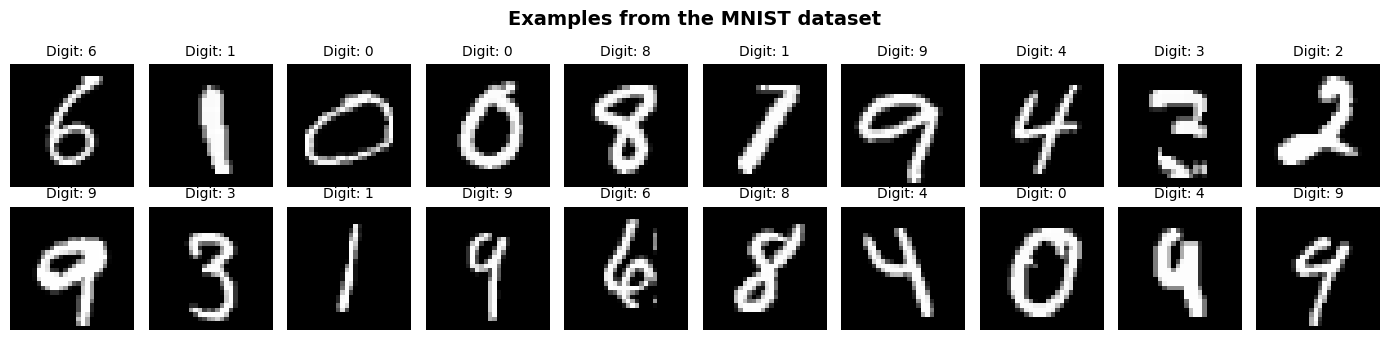

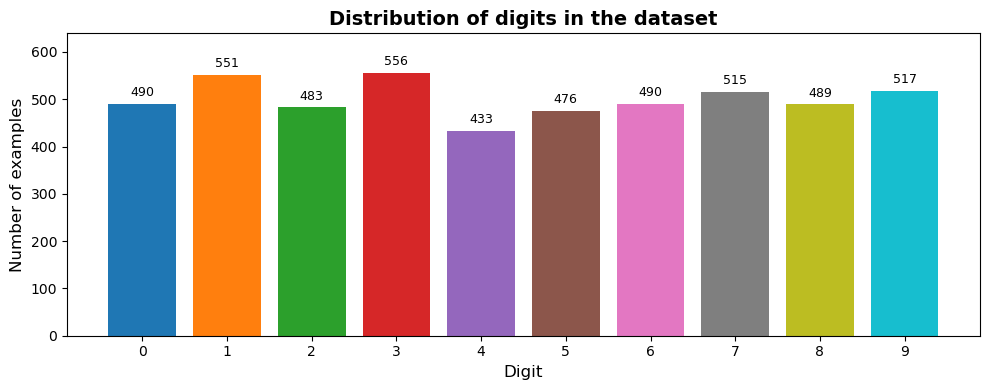


📊 The dataset contains 5000 images distributed across 10 digit classes.
📐 Each image is 28×28 = 784 pixels (grayscale, values 0-1).


In [61]:
# =============================================================================
# VISUALIZE MNIST EXAMPLES
# =============================================================================
# This function creates two visualizations:
#   1. A grid of sample digit images (to see what the data looks like)
#   2. A bar chart showing class distribution (to check for class imbalance)
#
# Why visualize?
#   - Essential first step in any ML project ("look at your data!")
#   - Helps identify data quality issues (corrupted images, mislabeled data)
#   - Reveals class imbalance that might affect model training

def show_mnist_examples(data, n_examples=20, random_selection=True):
    """
    Display a grid of MNIST digits and show the distribution of classes.
    
    Args:
        data: DataFrame with 784 pixel columns (pixel_0 to pixel_783) and 'label' column
        n_examples: Number of example images to display (default: 20)
        random_selection: If True, pick random samples; if False, show first n samples
    
    Returns:
        None (displays plots inline)
    """
    # --- PART 1: Create grid of sample images ---
    
    # Calculate grid dimensions: 2 rows × 10 columns = 20 images
    n_rows = 2
    n_cols = n_examples // n_rows  # Integer division: 20 // 2 = 10
    
    # Create subplot grid
    # figsize=(14, 3.5): wide figure to fit 10 images per row
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3.5))
    fig.suptitle('Examples from the MNIST dataset', fontsize=14, fontweight='bold')
    
    # Select which images to display
    if random_selection:
        np.random.seed(42)  # Fixed seed → same images every run (reproducibility)
        indices = np.random.choice(len(data), n_examples, replace=False)
    else:
        indices = range(n_examples)  # Just take first 20 images
    
    # Loop through each subplot and display an image
    # axes.flat: flattens 2D array of axes into 1D for easy iteration
    for idx, ax in enumerate(axes.flat):
        i = indices[idx]  # Get the actual row index in the DataFrame
        
        # Extract pixel values and reshape from flat (784,) to 2D (28, 28)
        # data.iloc[i, :-1]: row i, all columns except last (which is 'label')
        pixels = data.iloc[i, :-1].values.reshape(28, 28)
        label = int(data.iloc[i]['label'])  # The true digit (0-9)
        
        # Display image using grayscale colormap (0=black, 1=white)
        ax.imshow(pixels, cmap='gray')
        ax.set_title(f'Digit: {label}', fontsize=10)
        ax.axis('off')  # Hide axis ticks (cleaner look for images)
    
    plt.tight_layout()  # Adjust spacing to prevent overlap
    plt.show()
    
    # --- PART 2: Show class distribution (bar chart) ---
    # Why? To check if classes are balanced (roughly equal samples per digit)
    # Imbalanced data can cause models to be biased toward majority classes
    
    fig2, ax2 = plt.subplots(figsize=(10, 4))
    
    # Count samples per digit and sort by digit (0, 1, 2, ..., 9)
    digit_distribution = data['label'].value_counts().sort_index()
    
    # Use tab10 colormap: 10 distinct colors, one per digit
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    
    # Create bar chart
    bars = ax2.bar(digit_distribution.index, digit_distribution.values, color=colors)
    ax2.set_xlabel('Digit', fontsize=12)
    ax2.set_ylabel('Number of examples', fontsize=12)
    ax2.set_title('Distribution of digits in the dataset', fontsize=14, fontweight='bold')
    ax2.set_xticks(range(10))  # Ensure x-axis shows 0-9
    
    # Add extra space at top for labels (extend y-axis by 15% above max bar)
    max_height = digit_distribution.values.max()
    ax2.set_ylim(0, max_height * 1.15)
    
    # Add exact count labels above each bar (easier to read precise values)
    for bar, count in zip(bars, digit_distribution.values):
        ax2.text(bar.get_x() + bar.get_width()/2,  # x: center of bar
                bar.get_height() + 10,              # y: slightly above bar
                str(count),                         # text: the count
                ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # --- PART 3: Print summary statistics ---
    print(f"\n📊 The dataset contains {len(data)} images distributed across 10 digit classes.")
    print(f"📐 Each image is {28}×{28} = 784 pixels (grayscale, values 0-1).")

# === Run the visualization ===
show_mnist_examples(mnist_data)


### Define classes and their functions

#### Quick Python primer: Functions and Classes

**Functions** are reusable blocks of code that perform a specific task. Think of them like medical procedures:

```python
def measure_blood_pressure(patient):
    # ... perform measurement ...
    return systolic, diastolic
```

You define a function once, then call it many times with different inputs.

**Classes** are blueprints for creating objects that bundle data and functions together. A medical analogy:

| Programming concept | Medical analogy |
|---------------------|-----------------|
| **Class** | A template for a type of medical device (e.g., "ECG machine") |
| **Object/Instance** | A specific device in your clinic (e.g., "the ECG in Room 3") |
| **Attributes** | The device's properties (e.g., manufacturer, calibration date) |
| **Methods** | What the device can do (e.g., `record()`, `display_rhythm()`) |

```python
class ECGMachine:
    def __init__(self, room):       # Constructor: called when creating new instance
        self.room = room            # Attribute: stores data
    
    def record(self, patient):      # Method: a function inside the class
        # ... record ECG ...
        return ecg_data
```

---

#### Our two classes

In the following cells, we define two Python classes:

1. **`SimpleCNN`** – The neural network model itself. This class inherits from PyTorch's `nn.Module` and defines:
   - The **architecture** (layers): what components the network has
   - The **forward pass**: how data flows through the network
   - Think of it as the "brain" that learns to recognize digits

2. **`CNNVisualizer`** – A helper class for creating visualizations:
   - `draw_architecture()`: diagram of the network structure
   - `visualize_convolution()`: step-by-step convolution demo
   - `visualize_feature_maps()`: what each layer "sees"
   - This separates visualization logic from the model itself

**Why organize code into classes?**
- **Encapsulation**: Bundles related data and functions together
- **Reusability**: Create multiple instances or extend functionality easily
- **Clarity**: Code is organized logically, easier to understand and maintain
- **PyTorch convention**: Neural networks are always defined as classes inheriting from `nn.Module`

The cells below build up these classes step by step, with detailed comments explaining each part.

SimpleCNN architecture defined successfully!
  Layer summary (matching the architecture diagram):
  - Input:  28×28×1 (grayscale image)
  - Conv1:  28×28×1  → 26×26×32  (3×3 kernel, 32 filters)
  - Pool1:  26×26×32 → 13×13×32  (2×2 max pooling)
  - Conv2:  13×13×32 → 11×11×64  (3×3 kernel, 64 filters)
  - Pool2:  11×11×64 → 5×5×64    (2×2 max pooling)
  - FC1:    1600 → 128 neurons   (5×5×64 = 1600 flattened)
  - FC2:    128 → 10 classes     (one per digit 0-9)


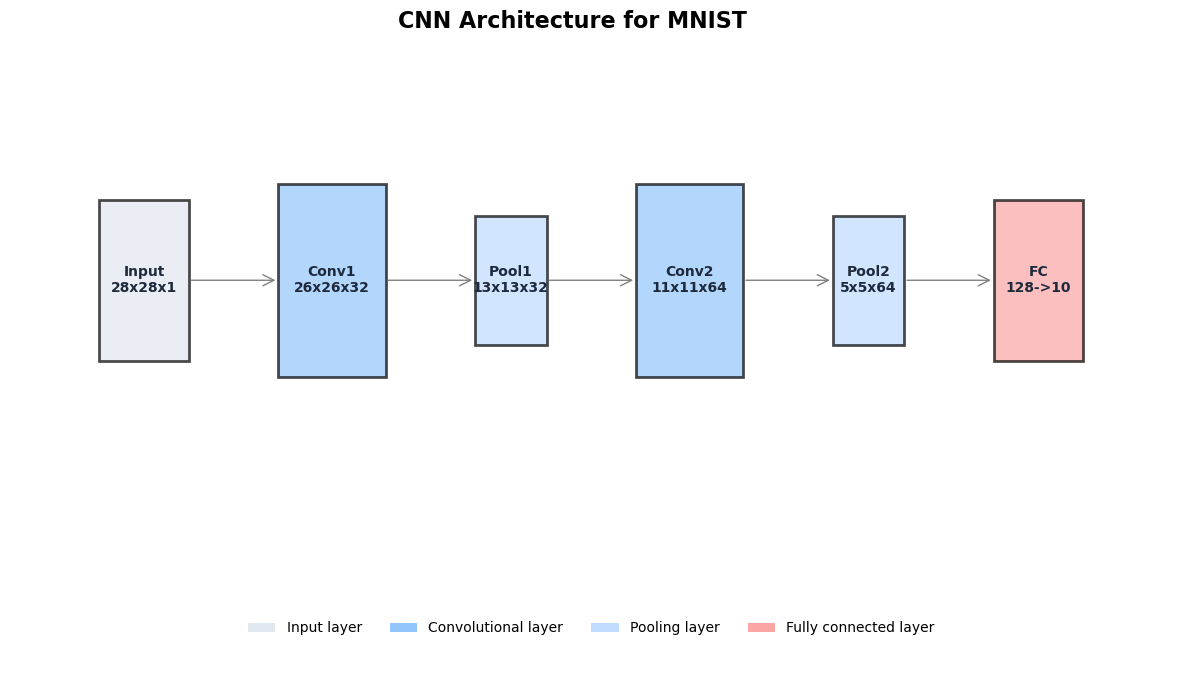

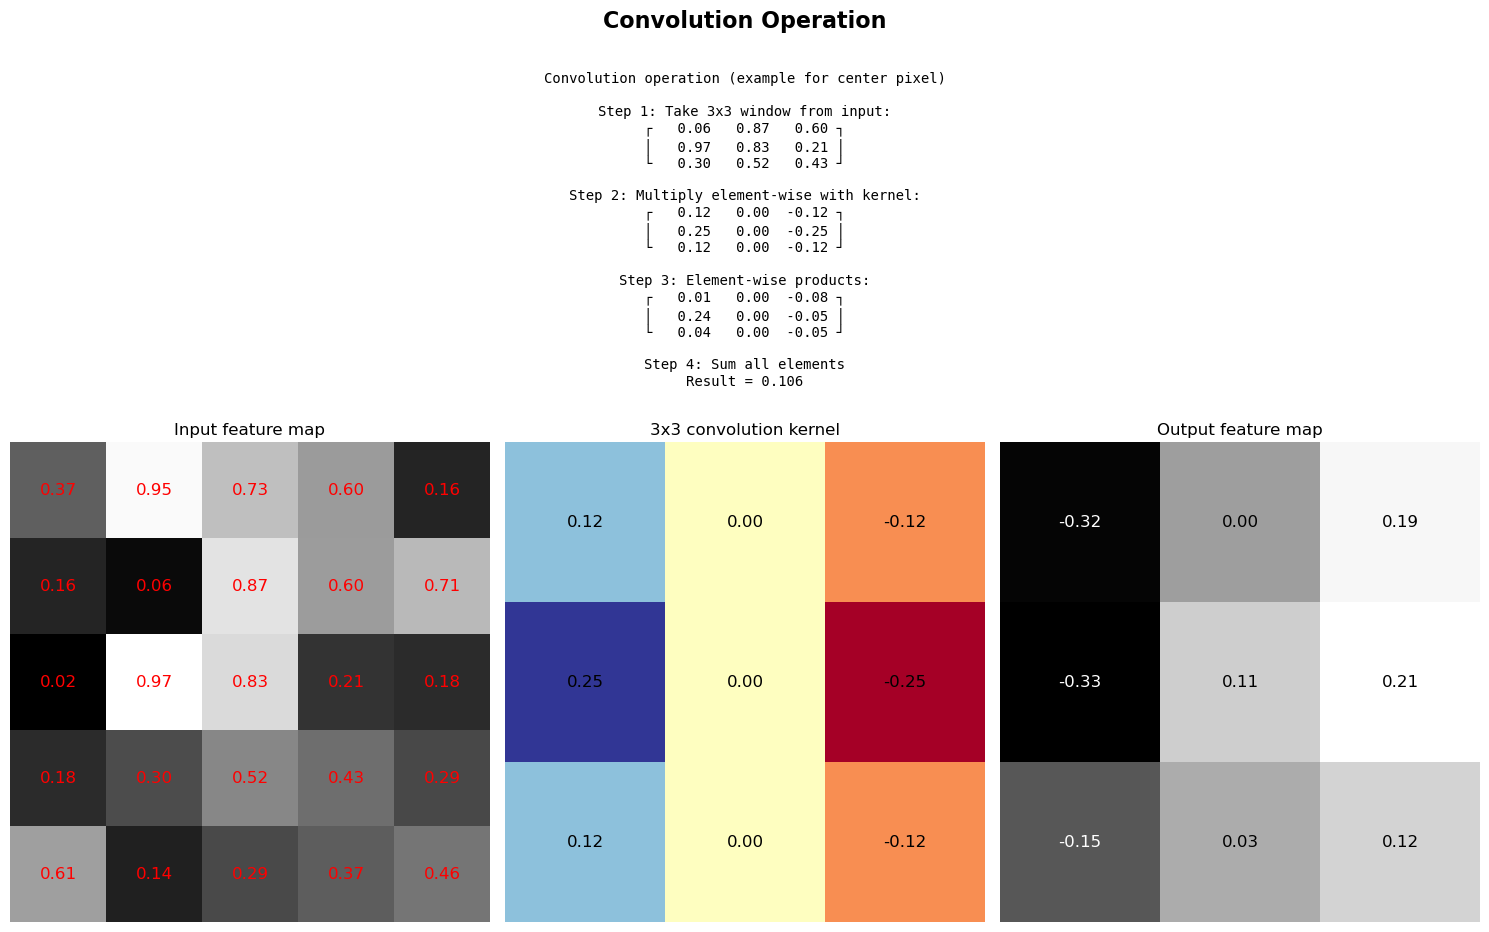

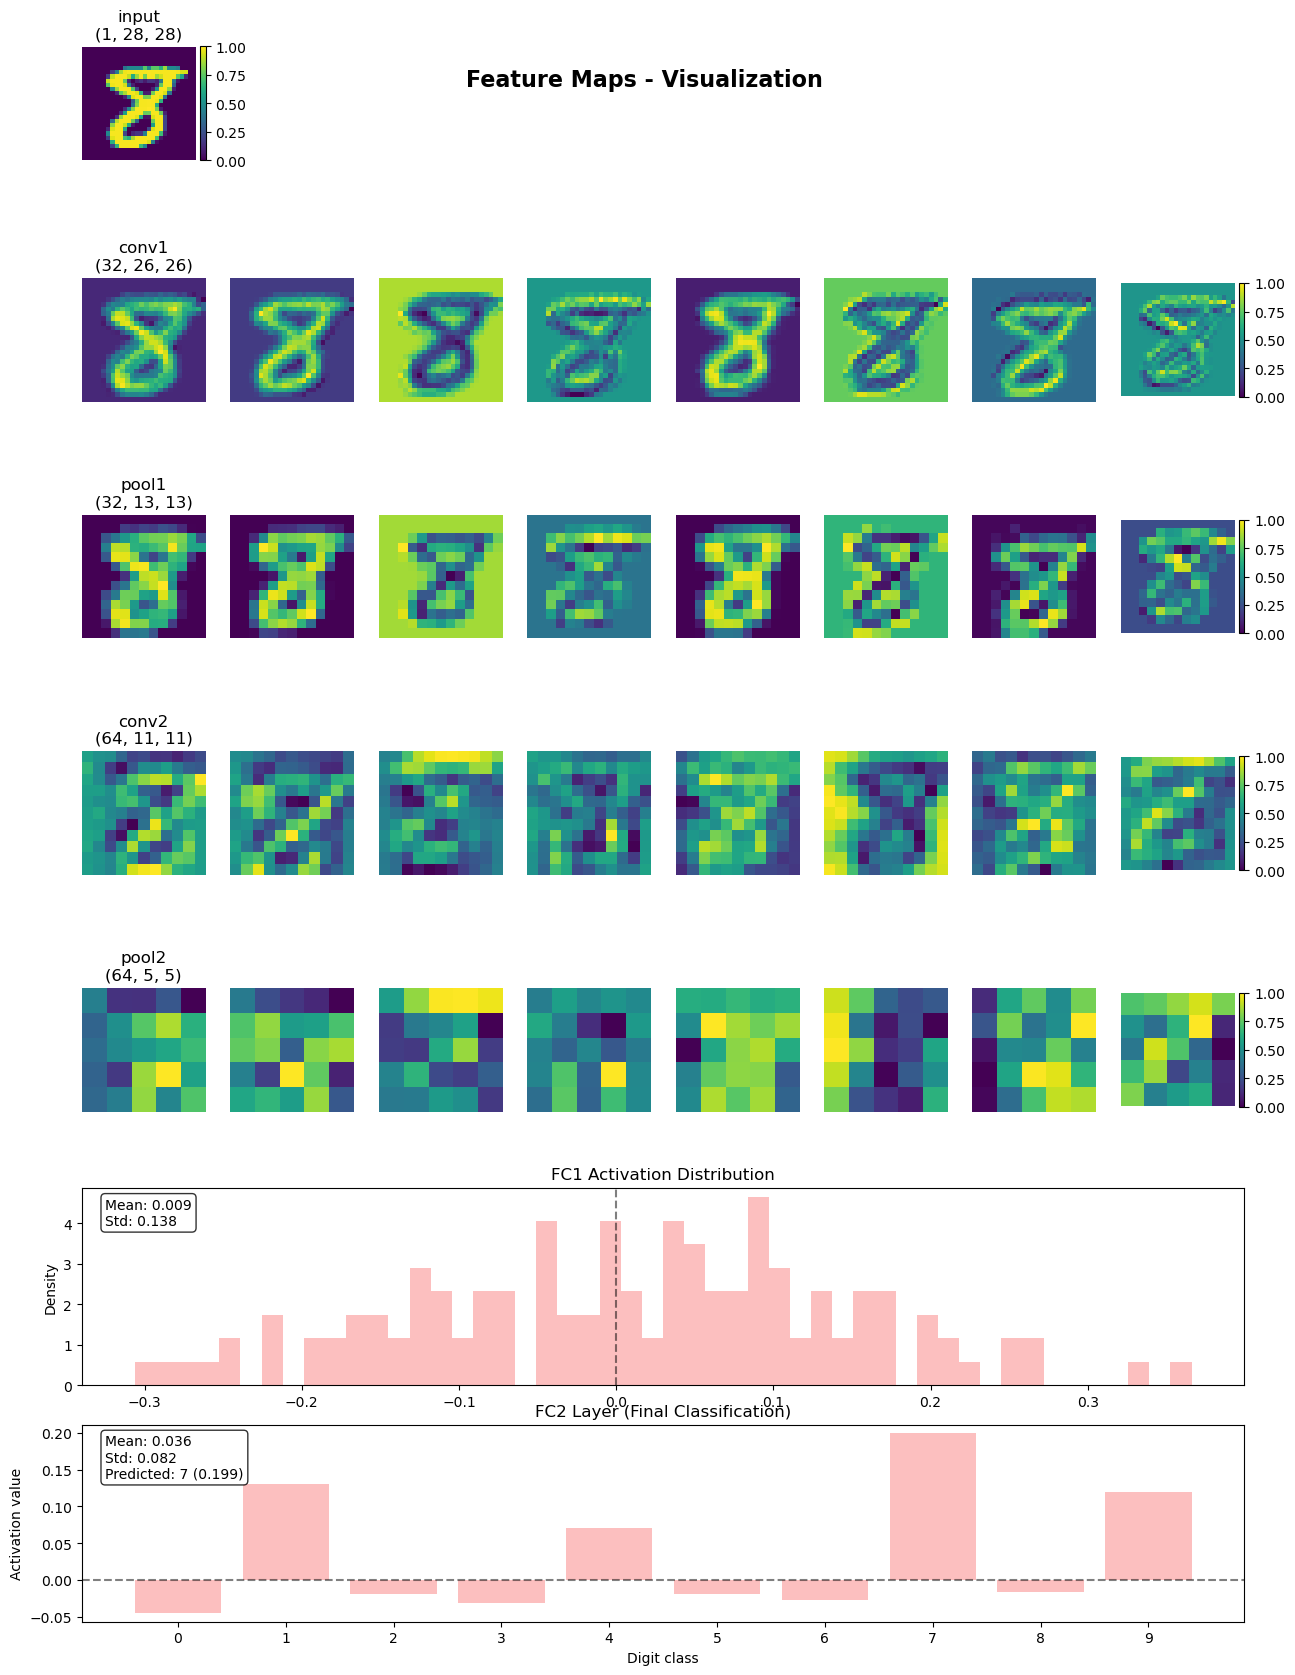

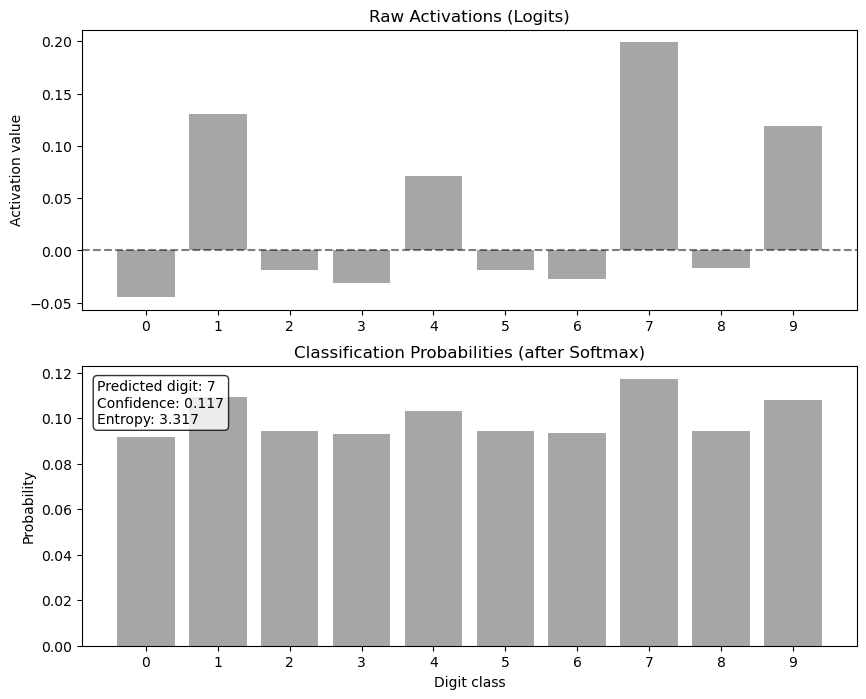

In [62]:
# =============================================================================
# PART 1: DEFINE THE CNN MODEL (SimpleCNN)
# =============================================================================
# This class defines our Convolutional Neural Network architecture.
# 
# WHY USE A CNN FOR IMAGES?
#   - Traditional neural networks treat each pixel independently
#   - CNNs exploit spatial structure: nearby pixels are related
#   - Convolutional layers learn local patterns (edges, textures)
#   - Same filter applied across entire image → translation invariance
#
# ARCHITECTURE OVERVIEW:
#   Input (28×28×1) → Conv1 → Pool1 → Conv2 → Pool2 → FC1 → FC2 → Output (10)
#
# Medical analogy: Like examining a tissue sample at different magnifications,
# each layer extracts increasingly abstract features.

class SimpleCNN(nn.Module):
    """
    Simple CNN architecture for MNIST digit classification.
    
    Architecture:
        Conv1 (32 filters) → MaxPool → Conv2 (64 filters) → MaxPool → FC1 → FC2
    
    Input:  28×28 grayscale image (1 channel)
    Output: 10 class probabilities (digits 0-9)
    """
    
    def __init__(self):
        # Initialize parent class (nn.Module) - required for PyTorch
        super().__init__()
        
        # --- CONVOLUTIONAL LAYERS ---
        # These layers detect spatial patterns (edges, curves, shapes)
        
        # Conv1: First convolutional layer
        #   - in_channels=1:   grayscale input (1 channel)
        #   - out_channels=32: learn 32 different filters/patterns
        #   - kernel_size=3:   3×3 sliding window
        #   - Output size: 28-3+1 = 26 → shape becomes 26×26×32
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3)
        
        # Pool1: Downsample by taking max value in 2×2 windows
        #   - Reduces spatial size by half: 26→13
        #   - Makes features more robust to small translations
        #   - Output shape: 13×13×32
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Conv2: Second convolutional layer
        #   - in_channels=32:  receives 32 feature maps from Pool1
        #   - out_channels=64: learn 64 higher-level patterns
        #   - Output size: 13-3+1 = 11 → shape becomes 11×11×64
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)
        
        # Pool2: Second max pooling
        #   - 11→5 (actually 11/2 = 5.5, truncated to 5)
        #   - Output shape: 5×5×64 = 1600 values
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # --- FULLY CONNECTED LAYERS ---
        # These layers combine all features for final classification
        
        # FC1: Flatten spatial features into 1D vector, reduce to 128 neurons
        #   - Input: 64 channels × 5 × 5 = 1600 features
        #   - Output: 128 neurons (compressed representation)
        self.fc1 = nn.Linear(in_features=64 * 5 * 5, out_features=128)
        
        # FC2: Final classification layer
        #   - Input: 128 neurons
        #   - Output: 10 neurons (one per digit class 0-9)
        self.fc2 = nn.Linear(in_features=128, out_features=10)

    def forward(self, x):
        """
        Forward pass: defines how data flows through the network.
        
        Args:
            x: Input tensor of shape (batch_size, 1, 28, 28)
        
        Returns:
            output: Class scores of shape (batch_size, 10)
            layers: Dictionary of intermediate activations for visualization
        """
        # Store intermediate outputs for visualization
        layers = {}
        
        # Input: original image
        layers['input'] = x  # Shape: (batch, 1, 28, 28)
        
        # Conv1: Apply 32 filters to detect basic patterns
        x = self.conv1(x)
        layers['conv1'] = x  # Shape: (batch, 32, 26, 26)
        
        # Pool1: Downsample to reduce computation and add invariance
        x = self.pool1(x)
        layers['pool1'] = x  # Shape: (batch, 32, 13, 13)
        
        # Conv2: Apply 64 filters to detect complex patterns
        x = self.conv2(x)
        layers['conv2'] = x  # Shape: (batch, 64, 11, 11)
        
        # Pool2: Final spatial downsampling
        x = self.pool2(x)
        layers['pool2'] = x  # Shape: (batch, 64, 5, 5)
        
        # Flatten: Convert 3D feature maps to 1D vector
        # view(-1, ...): -1 means "infer batch size automatically"
        x = x.view(-1, 64 * 5 * 5)  # Shape: (batch, 1600)
        
        # FC1: Dense layer for feature combination
        x = self.fc1(x)
        layers['fc1'] = x  # Shape: (batch, 128)
        
        # FC2: Output layer (raw scores, called "logits")
        x = self.fc2(x)
        layers['fc2'] = x  # Shape: (batch, 10)
        
        return x, layers


# =============================================================================
# VERIFY THE MODEL ARCHITECTURE
# =============================================================================
# The summary below describes what we defined in the SimpleCNN class:
#
#   CLASS DEFINITION                    →  WHAT IT CREATES
#   ─────────────────────────────────────────────────────────────────
#   self.conv1 = nn.Conv2d(1, 32, 3)    →  Conv1: 32 filters, 3×3 kernel
#   self.pool1 = nn.MaxPool2d(2, 2)     →  Pool1: 2×2 max pooling
#   self.conv2 = nn.Conv2d(32, 64, 3)   →  Conv2: 64 filters, 3×3 kernel
#   self.pool2 = nn.MaxPool2d(2, 2)     →  Pool2: 2×2 max pooling
#   self.fc1 = nn.Linear(1600, 128)     →  FC1: 1600→128 neurons
#   self.fc2 = nn.Linear(128, 10)       →  FC2: 128→10 (classification)
#
# The forward() method then defines HOW data flows through these layers:
#   input → conv1 → pool1 → conv2 → pool2 → flatten → fc1 → fc2 → output
#
# =============================================================================
# UNDERSTANDING FILTERS AND FULLY CONNECTED LAYERS
# =============================================================================
#
# CONV1 FILTERS (32 filters):
#   - Each filter is a 3×3 pattern detector that slides across the image
#   - Filters are LEARNED during training (initially random weights)
#   - Early filters typically learn to detect simple features:
#       • Horizontal edges (─), vertical edges (│), diagonal edges (╱ ╲)
#       • Corners, blobs, gradients
#   - Medical analogy: Like using 32 different "stains" on a tissue sample,
#     each highlighting a different basic structure
#   - Output: 32 "feature maps" showing WHERE each pattern was detected
#
# CONV2 FILTERS (64 filters):
#   - Each filter now looks at COMBINATIONS of Conv1 features
#   - Learns more complex, abstract patterns:
#       • Curves, loops, intersections
#       • Parts of digits: the loop in "6", the cross in "4"
#   - Medical analogy: Combining basic findings into patterns
#     (e.g., "round nucleus + pink cytoplasm + clustered cells")
#   - Output: 64 feature maps of higher-level patterns
#
# FULLY CONNECTED LAYERS (FC1, FC2):
#   - Unlike Conv layers, FC layers connect EVERY input to EVERY output
#   - They lose spatial information but can learn complex combinations
#
#   FC1 (1600 → 128 neurons):
#       • Takes all 1600 features (5×5×64 flattened) as input
#       • Compresses into 128 abstract "concepts"
#       • Each neuron represents a learned combination of features
#       • Medical analogy: Integrating all findings into a differential diagnosis
#
#   FC2 (128 → 10 neurons):
#       • The final "decision" layer - one neuron per digit class (0-9)
#       • Each output is a "score" (logit) for that digit
#       • Higher score = more confident the input is that digit
#       • Apply softmax to convert scores → probabilities that sum to 1
#       • Medical analogy: Final diagnosis with confidence levels
#
# =============================================================================
# The print statements below are a human-readable summary of this architecture.
# =============================================================================

print("SimpleCNN architecture defined successfully!")
print("  Layer summary (matching the architecture diagram):")
print(f"  - Input:  28×28×1 (grayscale image)")
print(f"  - Conv1:  28×28×1  → 26×26×32  (3×3 kernel, 32 filters)")
print(f"  - Pool1:  26×26×32 → 13×13×32  (2×2 max pooling)")
print(f"  - Conv2:  13×13×32 → 11×11×64  (3×3 kernel, 64 filters)")
print(f"  - Pool2:  11×11×64 → 5×5×64    (2×2 max pooling)")
print(f"  - FC1:    1600 → 128 neurons   (5×5×64 = 1600 flattened)")
print(f"  - FC2:    128 → 10 classes     (one per digit 0-9)")


class CNNVisualizer:
    """Class for visualizing CNN architecture and feature maps."""
    
    def __init__(self):
        self.colors = {
            'input': '#e2e8f0',
            'conv': '#93c5fd',
            'pool': '#bfdbfe',
            'fc': '#fca5a5',
            'text': '#1e293b'
        }
        
    def draw_architecture(self, save_path=None):
        """Draw CNN architecture diagram."""
        fig = plt.figure(figsize=(15, 8))
        gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.3)
        ax_arch = fig.add_subplot(gs[0])
        ax_legend = fig.add_subplot(gs[1])
        
        # Layer configuration
        layer_list = [
            {'name': 'Input\n28x28x1', 'type': 'input', 'width': 1.0},
            {'name': 'Conv1\n26x26x32', 'type': 'conv', 'width': 1.2},
            {'name': 'Pool1\n13x13x32', 'type': 'pool', 'width': 0.8},
            {'name': 'Conv2\n11x11x64', 'type': 'conv', 'width': 1.2},
            {'name': 'Pool2\n5x5x64', 'type': 'pool', 'width': 0.8},
            {'name': 'FC\n128->10', 'type': 'fc', 'width': 1.0}
        ]
        
        # Draw layers
        x_offset = 1
        for i, layer in enumerate(layer_list):
            height = layer['width'] * 1.5
            width = layer['width']
            y_pos = (4 - height) / 2
            
            rect = patches.Rectangle(
                (x_offset, y_pos), width, height,
                facecolor=self.colors[layer['type']],
                edgecolor='black', alpha=0.7, linewidth=2
            )
            ax_arch.add_patch(rect)
            
            ax_arch.text(
                x_offset + width/2, y_pos + height/2, layer['name'],
                ha='center', va='center',
                color=self.colors['text'], fontsize=10, fontweight='bold'
            )
            
            if i < len(layer_list) - 1:
                arrow = FancyArrowPatch(
                    (x_offset + width, y_pos + height/2),
                    (x_offset + width + 1, y_pos + height/2),
                    arrowstyle='->', mutation_scale=20, color='gray'
                )
                ax_arch.add_patch(arrow)
            
            x_offset += width + 1
        
        ax_arch.set_xlim(0, x_offset)
        ax_arch.set_ylim(0, 4)
        ax_arch.axis('off')
        
        # Add legend
        legend_elements = [
            patches.Patch(facecolor=self.colors['input'], label='Input layer'),
            patches.Patch(facecolor=self.colors['conv'], label='Convolutional layer'),
            patches.Patch(facecolor=self.colors['pool'], label='Pooling layer'),
            patches.Patch(facecolor=self.colors['fc'], label='Fully connected layer')
        ]
        ax_legend.legend(handles=legend_elements, loc='center', ncol=4, frameon=False)
        ax_legend.axis('off')
        
        plt.suptitle('CNN Architecture for MNIST', fontsize=16, fontweight='bold', y=0.95)
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            
        return fig


    def visualize_classification(self, activations, save_path=None):
        """
        Visualize classification results from the FC2 layer.
        
        Args:
            activations: Raw activation values from the FC2 layer
            save_path: Path to save the visualization
        """
        # Convert to probabilities with softmax
        probabilities = torch.softmax(torch.tensor(activations), dim=0).numpy()
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), height_ratios=[1, 1])
        
        # Plot raw activations
        x = np.arange(len(activations))
        ax1.bar(x, activations, alpha=0.7, color='gray')
        ax1.set_xticks(x)
        ax1.set_xticklabels([str(i) for i in range(10)])
        ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
        ax1.set_title('Raw Activations (Logits)')
        ax1.set_ylabel('Activation value')
        
        # Plot probabilities
        ax2.bar(x, probabilities, alpha=0.7, color='gray')
        ax2.set_xticks(x)
        ax2.set_xticklabels([str(i) for i in range(10)])
        ax2.set_title('Classification Probabilities (after Softmax)')
        ax2.set_xlabel('Digit class')
        ax2.set_ylabel('Probability')
        
        # Add statistics
        predicted_digit = np.argmax(probabilities)
        max_probability = np.max(probabilities)
        entropy = -np.sum(probabilities * np.log2(probabilities + 1e-10))
        
        stats_text = (
            f'Predicted digit: {predicted_digit}\n'
            f'Confidence: {max_probability:.3f}\n'
            f'Entropy: {entropy:.3f}'
        )
        
        ax2.text(0.02, 0.95, stats_text, transform=ax2.transAxes,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        return fig


    def visualize_feature_maps(self, model, input_image, save_path=None):
        """Visualize feature maps at each layer in the CNN."""
        model.eval()
        
        with torch.no_grad():
            _, feature_maps = model(input_image)
        
        n_layers = len(feature_maps)
        n_cols = 8
        fig = plt.figure(figsize=(15, 3 * n_layers))
        
        for idx, (layer_name, feature_map) in enumerate(feature_maps.items()):
            feature_map = feature_map.squeeze(0)
            
            if layer_name in ['fc1', 'fc2']:
                ax = plt.subplot(n_layers, 1, idx + 1)
                data = feature_map.numpy()

                if layer_name == 'fc2':
                    x = np.arange(len(data))
                    ax.bar(x, data, alpha=0.7, color=self.colors['fc'])
                    ax.set_xticks(x)
                    ax.set_xticklabels([str(i) for i in range(10)])
                    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
                    
                    mean = np.mean(data)
                    std = np.std(data)
                    max_digit = np.argmax(data)
                    max_value = np.max(data)
                    
                    stats_text = (
                        f'Mean: {mean:.3f}\n'
                        f'Std: {std:.3f}\n'
                        f'Predicted: {max_digit} ({max_value:.3f})'
                    )
                    
                    ax.text(0.02, 0.95, stats_text, transform=ax.transAxes,
                        verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
                    
                    ax.set_title('FC2 Layer (Final Classification)')
                    ax.set_xlabel('Digit class')
                    ax.set_ylabel('Activation value')

                    class_fig = self.visualize_classification(data, 'classification.png')
                    
                else:
                    ax.hist(data, bins=50, density=True, alpha=0.7, color=self.colors['fc'])
                    ax.axvline(x=0, color='black', linestyle='--', alpha=0.5)
                    
                    mean = np.mean(data)
                    std = np.std(data)
                    ax.text(0.02, 0.95, 
                        f'Mean: {mean:.3f}\nStd: {std:.3f}',
                        transform=ax.transAxes, verticalalignment='top',
                        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
                    
                    ax.set_title('FC1 Activation Distribution')
                    ax.set_ylabel('Density')
                
            else:
                n_filters = min(n_cols, feature_map.shape[0])
                for i in range(n_filters):
                    ax = plt.subplot(n_layers, n_cols, idx * n_cols + i + 1)
                    
                    fm = feature_map[i].numpy()
                    vmin, vmax = fm.min(), fm.max()
                    if vmin != vmax:
                        fm = (fm - vmin) / (vmax - vmin)
                    
                    im = ax.imshow(fm, cmap='viridis')
                    ax.axis('off')
                    
                    if i == 0:
                        ax.set_title(f'{layer_name}\n{tuple(feature_map.shape)}')
                    
                    if i == n_filters - 1:
                        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
                plt.suptitle('Feature Maps - Visualization', 
                        fontsize=16, fontweight='bold', y=0.85)
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
        return fig  
     

    def visualize_convolution(self, save_path=None):
        """Visualize the convolution operation."""
        fig = plt.figure(figsize=(15, 10))
        gs = GridSpec(2, 3, height_ratios=[1, 2])
        
        ax_eq = fig.add_subplot(gs[0, :])
        ax1 = fig.add_subplot(gs[1, 0])
        ax2 = fig.add_subplot(gs[1, 1])
        ax3 = fig.add_subplot(gs[1, 2])
        
        np.random.seed(42)
        input_data = np.random.rand(5, 5)
        kernel = np.array([[1, 0, -1],
                          [2, 0, -2],
                          [1, 0, -1]]) / 8
        
        # Calculate output
        output = np.zeros((3, 3))
        for i in range(3):
            for j in range(3):
                output[i, j] = np.sum(input_data[i:i+3, j:j+3] * kernel)
        
        i, j = 1, 1
        window = input_data[i:i+3, j:j+3]
        result = output[i, j]
        products = window * kernel
        
        # Explanation with ASCII matrices
        eq_text = (
            "Convolution operation (example for center pixel)\n\n"
            "Step 1: Take 3x3 window from input:\n"
            f"┌ {window[0,0]:6.2f} {window[0,1]:6.2f} {window[0,2]:6.2f} ┐\n"
            f"│ {window[1,0]:6.2f} {window[1,1]:6.2f} {window[1,2]:6.2f} │\n"
            f"└ {window[2,0]:6.2f} {window[2,1]:6.2f} {window[2,2]:6.2f} ┘\n\n"
            "Step 2: Multiply element-wise with kernel:\n"
            f"┌ {kernel[0,0]:6.2f} {kernel[0,1]:6.2f} {kernel[0,2]:6.2f} ┐\n"
            f"│ {kernel[1,0]:6.2f} {kernel[1,1]:6.2f} {kernel[1,2]:6.2f} │\n"
            f"└ {kernel[2,0]:6.2f} {kernel[2,1]:6.2f} {kernel[2,2]:6.2f} ┘\n\n"
            "Step 3: Element-wise products:\n"
            f"┌ {products[0,0]:6.2f} {products[0,1]:6.2f} {products[0,2]:6.2f} ┐\n"
            f"│ {products[1,0]:6.2f} {products[1,1]:6.2f} {products[1,2]:6.2f} │\n"
            f"└ {products[2,0]:6.2f} {products[2,1]:6.2f} {products[2,2]:6.2f} ┘\n\n"
            "Step 4: Sum all elements\n"
            f"Result = {result:.3f}"
        )
        
        ax_eq.text(0.5, 0.5, eq_text, ha='center', va='center',
                transform=ax_eq.transAxes, fontsize=10, family='monospace')
        ax_eq.axis('off')
        
        # Plot input
        im1 = ax1.imshow(input_data, cmap='gray')
        for i in range(input_data.shape[0]):
            for j in range(input_data.shape[1]):
                ax1.text(j, i, f'{input_data[i, j]:.2f}',
                        ha='center', va='center', color='red', fontsize=12)
        ax1.set_title('Input feature map')
        ax1.axis('off')
        
        # Plot kernel
        im2 = ax2.imshow(kernel, cmap='RdYlBu')
        for i in range(kernel.shape[0]):
            for j in range(kernel.shape[1]):
                ax2.text(j, i, f'{kernel[i, j]:.2f}',
                        ha='center', va='center', color='black', fontsize=12)
        ax2.set_title('3x3 convolution kernel')
        ax2.axis('off')
        
        # Plot output
        im3 = ax3.imshow(output, cmap='gray')
        for i in range(output.shape[0]):
            for j in range(output.shape[1]):
                pixel_value = output[i, j]
                normalized = (pixel_value - output.min()) / (output.max() - output.min())
                text_color = 'white' if normalized < 0.5 else 'black'
                ax3.text(j, i, f'{pixel_value:.2f}',
                        ha='center', va='center', color=text_color, fontsize=12)
        ax3.set_title('Output feature map')
        ax3.axis('off')
        
        plt.suptitle('Convolution Operation', fontsize=16, fontweight='bold')
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            
        return fig


# === Run visualization ===
if __name__ == "__main__":
    # Create visualizer
    visualizer = CNNVisualizer()
    
    # Draw and save architecture
    arch_fig = visualizer.draw_architecture(save_path='mnist_images/cnn_architecture.png')
    
    # Draw and save convolution operation
    conv_fig = visualizer.visualize_convolution(save_path='mnist_images/convolution.png')
    
    # Create model with reproducible weights
    torch.manual_seed(42)
    model = SimpleCNN()

    # Load and preprocess the MNIST image
    if is_colab:
        import requests
        import io
        from PIL import Image

        url = 'https://raw.githubusercontent.com/arvidl/BMED365-2026/main/Lab2-DL/data/mnist_image_0000.png'
        response = requests.get(url, stream=True).raw
        image = Image.open(response)
        img = np.array(image)
    else:
        img_path = "../data/mnist_image_0000.png"
        img = plt.imread(img_path)
    
    # Convert RGBA to grayscale if necessary
    if len(img.shape) == 3:
        img = img[:, :, 0]
    
    # Convert to tensor and add batch and channel dimensions
    input_image = torch.from_numpy(img).float()
    input_image = input_image.unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, 28, 28)
  
    # Visualize feature maps with MNIST image
    feature_fig = visualizer.visualize_feature_maps(
        model, input_image, save_path='mnist_images/feature_maps.png'
    )
    
    plt.show()

In [63]:
# =============================================================================
# PART 2: CNN VISUALIZER CLASS - Architecture Diagram
# =============================================================================
# This class provides tools to visualize:
#   1. The CNN architecture as a diagram
#   2. The convolution operation step-by-step
#   3. Feature maps at each layer
#
# WHY VISUALIZE?
#   - CNNs are often called "black boxes" - visualization helps understand them
#   - Seeing feature maps reveals what patterns each layer detects
#   - Essential for debugging and explaining AI decisions in medicine

class CNNVisualizer:
    """
    Visualization toolkit for understanding CNN architectures and operations.
    
    Provides methods to:
        - draw_architecture(): Create a diagram of the network structure
        - visualize_convolution(): Show how convolution works step-by-step
        - visualize_feature_maps(): Display what each layer "sees"
        - visualize_classification(): Show prediction probabilities
    """
    
    def __init__(self):
        """Initialize color scheme for consistent visualizations."""
        # Color palette matching layer types (like different stains in histology)
        self.colors = {
            'input': '#e2e8f0',  # Light gray: raw data
            'conv': '#93c5fd',   # Blue: convolutional layers (pattern detection)
            'pool': '#bfdbfe',   # Light blue: pooling layers (downsampling)
            'fc': '#fca5a5',     # Red: fully connected layers (decision making)
            'text': '#1e293b'    # Dark gray: text labels
        }
        
    def draw_architecture(self, save_path=None):
        """
        Draw a visual diagram of the CNN architecture.
        
        Creates a horizontal flow diagram showing:
            Input → Conv1 → Pool1 → Conv2 → Pool2 → FC layers
        
        Args:
            save_path: Optional path to save the figure as PNG
        
        Returns:
            matplotlib Figure object
        """
        # Create figure with two rows: architecture diagram + legend
        fig = plt.figure(figsize=(15, 8))
        gs = GridSpec(2, 1, height_ratios=[4, 1], hspace=0.3)
        ax_arch = fig.add_subplot(gs[0])    # Main architecture diagram
        ax_legend = fig.add_subplot(gs[1])  # Legend below
        
        # Define each layer's properties for visualization
        # 'width' controls the visual size (larger = more complex layer)
        layer_list = [
            {'name': 'Input\n28x28x1', 'type': 'input', 'width': 1.0},
            {'name': 'Conv1\n26x26x32', 'type': 'conv', 'width': 1.2},
            {'name': 'Pool1\n13x13x32', 'type': 'pool', 'width': 0.8},
            {'name': 'Conv2\n11x11x64', 'type': 'conv', 'width': 1.2},
            {'name': 'Pool2\n5x5x64', 'type': 'pool', 'width': 0.8},
            {'name': 'FC\n128→10', 'type': 'fc', 'width': 1.0}
        ]
        
        # Draw each layer as a colored rectangle
        x_offset = 1  # Starting x position
        for i, layer in enumerate(layer_list):
            height = layer['width'] * 1.5
            width = layer['width']
            y_pos = (4 - height) / 2  # Center vertically
            
            # Create rectangle with layer-type-specific color
            rect = patches.Rectangle(
                (x_offset, y_pos), width, height,
                facecolor=self.colors[layer['type']],
                edgecolor='black', alpha=0.7, linewidth=2
            )
            ax_arch.add_patch(rect)
            
            # Add layer name inside rectangle
            ax_arch.text(
                x_offset + width/2, y_pos + height/2, layer['name'],
                ha='center', va='center',
                color=self.colors['text'], fontsize=10, fontweight='bold'
            )
            
            # Draw arrow to next layer (except after last layer)
            if i < len(layer_list) - 1:
                arrow = FancyArrowPatch(
                    (x_offset + width, y_pos + height/2),      # Start: right edge
                    (x_offset + width + 1, y_pos + height/2),  # End: next layer
                    arrowstyle='->', mutation_scale=20, color='gray'
                )
                ax_arch.add_patch(arrow)
            
            x_offset += width + 1  # Move to next position
        
        # Configure axes
        ax_arch.set_xlim(0, x_offset)
        ax_arch.set_ylim(0, 4)
        ax_arch.axis('off')  # Hide axes for clean look
        
        # Create legend explaining color coding
        legend_elements = [
            patches.Patch(facecolor=self.colors['input'], label='Input layer'),
            patches.Patch(facecolor=self.colors['conv'], label='Convolutional layer'),
            patches.Patch(facecolor=self.colors['pool'], label='Pooling layer'),
            patches.Patch(facecolor=self.colors['fc'], label='Fully connected layer')
        ]
        ax_legend.legend(handles=legend_elements, loc='center', ncol=4, frameon=False)
        ax_legend.axis('off')
        
        plt.suptitle('CNN Architecture for MNIST', fontsize=16, fontweight='bold', y=0.95)
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            
        return fig

print("CNNVisualizer class defined (Part 1: Architecture diagram)")

CNNVisualizer class defined (Part 1: Architecture diagram)


In [64]:
# =============================================================================
# PART 2 (continued): CNN VISUALIZER - Convolution Visualization
# =============================================================================
# This extends the CNNVisualizer class with the convolution visualization method.
#
# =============================================================================
# WHY 5×5 INPUT → 3×3 OUTPUT? (Understanding Convolution Borders)
# =============================================================================
#
# When we slide a 3×3 kernel over a 5×5 input, the output shrinks!
#
# OUTPUT SIZE FORMULA:
#   output_size = input_size - kernel_size + 1
#   output_size = 5 - 3 + 1 = 3
#
# WHY DOES THIS HAPPEN? The kernel needs a full 3×3 neighborhood:
#
#   Input (5×5):                    Valid kernel positions:
#   ┌───┬───┬───┬───┬───┐          The kernel center (●) can only be placed
#   │ 0 │ 1 │ 2 │ 3 │ 4 │          where it has a full 3×3 neighborhood:
#   ├───┼───┼───┼───┼───┤
#   │ 5 │ 6 │ 7 │ 8 │ 9 │            ┌───┬───┬───┐
#   ├───┼───┼───┼───┼───┤            │ ● │ ● │ ● │  ← 3 valid positions
#   │10 │11 │12 │13 │14 │            ├───┼───┼───┤
#   ├───┼───┼───┼───┼───┤            │ ● │ ● │ ● │  ← 3 valid positions
#   │15 │16 │17 │18 │19 │            ├───┼───┼───┤
#   ├───┼───┼───┼───┼───┤            │ ● │ ● │ ● │  ← 3 valid positions
#   │20 │21 │22 │23 │24 │            └───┴───┴───┘
#   └───┴───┴───┴───┴───┘            = 3×3 = 9 output pixels
#
# WHAT HAPPENS AT BORDERS?
#   - The kernel CANNOT be centered on border pixels (positions 0,1,3,4,5,9,...)
#   - Why? There's no data outside the image to fill the 3×3 window
#   - This is called "valid" convolution (no padding)
#
# Example: Why can't we compute output for input pixel [0,0]?
#   - To center kernel at [0,0], we'd need pixels at [-1,-1], [-1,0], [0,-1]...
#   - These don't exist! The kernel would "hang off" the edge.
#
# ALTERNATIVES (not used here):
#   - "Same" padding: Add zeros around the border → output = input size
#   - "Full" padding: Add more zeros → output > input size
#
# IN OUR CNN:
#   - 28×28 input → 3×3 kernel → 26×26 output (28 - 3 + 1 = 26)
#   - We lose 1 pixel on each side (top, bottom, left, right)
#
# =============================================================================

# Add the visualize_convolution method to the existing class
def visualize_convolution(self, save_path=None):
    """
    Visualize the convolution operation step-by-step.
    
    Shows how a 3×3 kernel slides over an input to produce an output.
    This is the core operation that makes CNNs work!
    
    The visualization includes:
        1. Step-by-step calculation for one output pixel
        2. The input feature map (5×5 random values)
        3. The convolution kernel (3×3 Sobel edge detector)
        4. The resulting output feature map (3×3)
    
    Args:
        save_path: Optional path to save the figure
    
    Returns:
        matplotlib Figure object
    """
    # Create figure with 2 rows: explanation on top, images below
    fig = plt.figure(figsize=(15, 10))
    gs = GridSpec(2, 3, height_ratios=[1, 2])
    
    ax_eq = fig.add_subplot(gs[0, :])  # Equation/explanation (spans all columns)
    ax1 = fig.add_subplot(gs[1, 0])    # Input image
    ax2 = fig.add_subplot(gs[1, 1])    # Kernel
    ax3 = fig.add_subplot(gs[1, 2])    # Output
    
    # Generate reproducible random input (5×5 matrix)
    np.random.seed(42)
    input_data = np.random.rand(5, 5)
    
    # Define a Sobel-like edge detection kernel (normalized by /8)
    # This kernel detects vertical edges (left-right intensity changes)
    #   [+1  0  -1]     Positive left side, negative right side
    #   [+2  0  -2]  →  Amplified in center for stronger response
    #   [+1  0  -1]     Symmetric for smooth detection
    kernel = np.array([[1, 0, -1],
                      [2, 0, -2],
                      [1, 0, -1]]) / 8  # Normalize to prevent large outputs
    
    # --- CALCULATE CONVOLUTION OUTPUT ---
    # Output size: (input_size - kernel_size + 1) = 5 - 3 + 1 = 3
    output = np.zeros((3, 3))
    for i in range(3):
        for j in range(3):
            # Extract 3×3 window from input
            window = input_data[i:i+3, j:j+3]
            # Element-wise multiply and sum (the convolution operation)
            output[i, j] = np.sum(window * kernel)
    
    # Focus on center pixel [1,1] for detailed explanation
    i, j = 1, 1
    window = input_data[i:i+3, j:j+3]
    result = output[i, j]
    products = window * kernel
    
    # Create step-by-step explanation with ASCII matrices
    eq_text = (
        "Convolution operation (example for center pixel)\n\n"
        "Step 1: Take 3x3 window from input:\n"
        f"┌ {window[0,0]:6.2f} {window[0,1]:6.2f} {window[0,2]:6.2f} ┐\n"
        f"│ {window[1,0]:6.2f} {window[1,1]:6.2f} {window[1,2]:6.2f} │\n"
        f"└ {window[2,0]:6.2f} {window[2,1]:6.2f} {window[2,2]:6.2f} ┘\n\n"
        "Step 2: Multiply element-wise with kernel:\n"
        f"┌ {kernel[0,0]:6.2f} {kernel[0,1]:6.2f} {kernel[0,2]:6.2f} ┐\n"
        f"│ {kernel[1,0]:6.2f} {kernel[1,1]:6.2f} {kernel[1,2]:6.2f} │\n"
        f"└ {kernel[2,0]:6.2f} {kernel[2,1]:6.2f} {kernel[2,2]:6.2f} ┘\n\n"
        "Step 3: Element-wise products:\n"
        f"┌ {products[0,0]:6.2f} {products[0,1]:6.2f} {products[0,2]:6.2f} ┐\n"
        f"│ {products[1,0]:6.2f} {products[1,1]:6.2f} {products[1,2]:6.2f} │\n"
        f"└ {products[2,0]:6.2f} {products[2,1]:6.2f} {products[2,2]:6.2f} ┘\n\n"
        "Step 4: Sum all elements\n"
        f"Result = {result:.3f}"
    )
    
    ax_eq.text(0.5, 0.5, eq_text, ha='center', va='center',
            transform=ax_eq.transAxes, fontsize=10, family='monospace')
    ax_eq.axis('off')
    
    # --- PLOT INPUT FEATURE MAP ---
    im1 = ax1.imshow(input_data, cmap='gray')
    for i in range(input_data.shape[0]):
        for j in range(input_data.shape[1]):
            ax1.text(j, i, f'{input_data[i, j]:.2f}',
                    ha='center', va='center', color='red', fontsize=12)
    ax1.set_title('Input feature map (5×5)')
    ax1.axis('off')
    
    # --- PLOT KERNEL ---
    im2 = ax2.imshow(kernel, cmap='RdYlBu')  # Red-Yellow-Blue: shows +/- values
    for i in range(kernel.shape[0]):
        for j in range(kernel.shape[1]):
            ax2.text(j, i, f'{kernel[i, j]:.2f}',
                    ha='center', va='center', color='black', fontsize=12)
    ax2.set_title('3×3 convolution kernel\n(Sobel edge detector)')
    ax2.axis('off')
    
    # --- PLOT OUTPUT FEATURE MAP ---
    im3 = ax3.imshow(output, cmap='gray')
    for i in range(output.shape[0]):
        for j in range(output.shape[1]):
            pixel_value = output[i, j]
            # Choose text color for visibility (white on dark, black on light)
            normalized = (pixel_value - output.min()) / (output.max() - output.min())
            text_color = 'white' if normalized < 0.5 else 'black'
            ax3.text(j, i, f'{pixel_value:.2f}',
                    ha='center', va='center', color=text_color, fontsize=12)
    ax3.set_title('Output feature map (3×3)')
    ax3.axis('off')
    
    plt.suptitle('Convolution Operation', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
    return fig

# Attach method to the class
CNNVisualizer.visualize_convolution = visualize_convolution

print("CNNVisualizer extended with visualize_convolution method")

CNNVisualizer extended with visualize_convolution method


In [65]:
# =============================================================================
# PART 2 (continued): CNN VISUALIZER - Classification Visualization
# =============================================================================
# This adds the classification visualization method.

def visualize_classification(self, activations, save_path=None):
    """
    Visualize classification results from the final FC2 layer.
    
    Shows how raw network outputs (logits) are converted to probabilities
    using the softmax function, which is how CNNs make predictions.
    
    UNDERSTANDING THE OUTPUT:
        - Raw activations (logits): can be any real number, + or -
        - After softmax: probabilities that sum to 1.0
        - The class with highest probability is the prediction
    
    Args:
        activations: Raw activation values from FC2 layer (shape: 10)
        save_path: Optional path to save the figure
    
    Returns:
        matplotlib Figure object
    """
    # --- CONVERT LOGITS TO PROBABILITIES ---
    # Softmax formula: P(class_i) = exp(logit_i) / sum(exp(all_logits))
    # This ensures all outputs are positive and sum to 1
    probabilities = torch.softmax(torch.tensor(activations), dim=0).numpy()
    
    # Create figure with two subplots: raw activations and probabilities
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), height_ratios=[1, 1])
    
    # --- PLOT RAW ACTIVATIONS (LOGITS) ---
    # These are the direct outputs from the final layer, before softmax
    x = np.arange(len(activations))
    ax1.bar(x, activations, alpha=0.7, color='gray')
    ax1.set_xticks(x)
    ax1.set_xticklabels([str(i) for i in range(10)])
    ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)  # Reference line at 0
    ax1.set_title('Raw Activations (Logits) - Before Softmax')
    ax1.set_ylabel('Activation value')
    
    # --- PLOT PROBABILITIES (AFTER SOFTMAX) ---
    # These are interpretable as "confidence" in each class
    ax2.bar(x, probabilities, alpha=0.7, color='gray')
    ax2.set_xticks(x)
    ax2.set_xticklabels([str(i) for i in range(10)])
    ax2.set_title('Classification Probabilities (After Softmax)')
    ax2.set_xlabel('Digit class')
    ax2.set_ylabel('Probability')
    
    # --- COMPUTE AND DISPLAY STATISTICS ---
    predicted_digit = np.argmax(probabilities)  # Class with highest probability
    max_probability = np.max(probabilities)      # Confidence level
    
    # Entropy measures uncertainty: low = confident, high = uncertain
    # Formula: H = -sum(p * log2(p))
    # Max entropy for 10 classes = log2(10) ≈ 3.32 (uniform distribution)
    entropy = -np.sum(probabilities * np.log2(probabilities + 1e-10))
    
    stats_text = (
        f'Predicted digit: {predicted_digit}\n'
        f'Confidence: {max_probability:.1%}\n'
        f'Entropy: {entropy:.2f} bits\n'
        f'(Max entropy = 3.32 bits)'
    )
    
    ax2.text(0.02, 0.95, stats_text, transform=ax2.transAxes,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig

# Attach method to the class
CNNVisualizer.visualize_classification = visualize_classification

print("CNNVisualizer extended with visualize_classification method")

CNNVisualizer extended with visualize_classification method


In [66]:
# =============================================================================
# PART 2 (continued): CNN VISUALIZER - Feature Map Visualization
# =============================================================================
# This adds the feature map visualization method - the most insightful view!

def visualize_feature_maps(self, model, input_image, save_path=None):
    """
    Visualize feature maps at each layer in the CNN.
    
    This is like looking at what each "filter" in the network sees.
    Early layers detect simple patterns (edges), later layers detect complex ones.
    
    WHAT ARE FEATURE MAPS?
        - The output of each layer after processing the input
        - Conv layers: 2D images showing where patterns were detected
        - FC layers: 1D vectors of abstract features
    
    MEDICAL ANALOGY:
        - Like using different staining techniques in histology
        - Each filter highlights different tissue features
    
    Args:
        model: The CNN model (SimpleCNN instance)
        input_image: Input tensor of shape (1, 1, 28, 28)
        save_path: Optional path to save the figure
    
    Returns:
        matplotlib Figure object
    """
    # Set model to evaluation mode (disables dropout, batch norm training behavior)
    model.eval()
    
    # Disable gradient computation (we're only doing inference, not training)
    with torch.no_grad():
        # Forward pass: get predictions AND intermediate feature maps
        _, feature_maps = model(input_image)
    
    n_layers = len(feature_maps)
    n_cols = 8  # Show up to 8 feature maps per layer
    fig = plt.figure(figsize=(15, 3 * n_layers))
    
    # Iterate through each layer's feature maps
    for idx, (layer_name, feature_map) in enumerate(feature_maps.items()):
        # Remove batch dimension: (1, C, H, W) → (C, H, W)
        feature_map = feature_map.squeeze(0)
        
        # --- FULLY CONNECTED LAYERS: Show as histograms/bar charts ---
        if layer_name in ['fc1', 'fc2']:
            ax = plt.subplot(n_layers, 1, idx + 1)
            data = feature_map.numpy()

            if layer_name == 'fc2':
                # FC2 is the final classification layer (10 outputs)
                # Show as bar chart - one bar per digit class
                x = np.arange(len(data))
                ax.bar(x, data, alpha=0.7, color=self.colors['fc'])
                ax.set_xticks(x)
                ax.set_xticklabels([str(i) for i in range(10)])
                ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
                
                # Add statistics
                mean = np.mean(data)
                std = np.std(data)
                max_digit = np.argmax(data)
                max_value = np.max(data)
                
                stats_text = (
                    f'Mean: {mean:.3f}\n'
                    f'Std: {std:.3f}\n'
                    f'Predicted: {max_digit} ({max_value:.3f})'
                )
                
                ax.text(0.02, 0.95, stats_text, transform=ax.transAxes,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
                
                ax.set_title('FC2 Layer (Final Classification - 10 digit classes)')
                ax.set_xlabel('Digit class')
                ax.set_ylabel('Activation value')

                # Also create detailed classification visualization
                class_fig = self.visualize_classification(data, 'mnist_images/classification.png')
                
            else:
                # FC1 has 128 neurons - show as histogram of activation values
                ax.hist(data, bins=50, density=True, alpha=0.7, color=self.colors['fc'])
                ax.axvline(x=0, color='black', linestyle='--', alpha=0.5)
                
                mean = np.mean(data)
                std = np.std(data)
                ax.text(0.02, 0.95, 
                    f'Mean: {mean:.3f}\nStd: {std:.3f}',
                    transform=ax.transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
                
                ax.set_title('FC1 Activation Distribution (128 neurons)')
                ax.set_ylabel('Density')
            
        # --- CONVOLUTIONAL/POOLING LAYERS: Show as 2D images ---
        else:
            n_filters = min(n_cols, feature_map.shape[0])  # Show up to 8 filters
            
            for i in range(n_filters):
                ax = plt.subplot(n_layers, n_cols, idx * n_cols + i + 1)
                
                # Get single feature map and normalize to [0, 1] for display
                fm = feature_map[i].numpy()
                vmin, vmax = fm.min(), fm.max()
                if vmin != vmax:
                    fm = (fm - vmin) / (vmax - vmin)
                
                # Display feature map as image
                im = ax.imshow(fm, cmap='viridis')  # Viridis: good for showing patterns
                ax.axis('off')
                
                # Add title to first feature map in row
                if i == 0:
                    ax.set_title(f'{layer_name}\n{tuple(feature_map.shape)}')
                
                # Add colorbar to last feature map in row
                if i == n_filters - 1:
                    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
            plt.suptitle('Feature Maps - Visualization', 
                    fontsize=16, fontweight='bold', y=0.85)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig

# Attach method to the class
CNNVisualizer.visualize_feature_maps = visualize_feature_maps

print("CNNVisualizer extended with visualize_feature_maps method")
print("\nCNNVisualizer class is now complete with all methods:")

CNNVisualizer extended with visualize_feature_maps method

CNNVisualizer class is now complete with all methods:


✓ Visualizer created
✓ Architecture diagram saved to mnist_images/cnn_architecture.png
✓ Convolution visualization saved to mnist_images/convolution.png
✓ SimpleCNN model created with reproducible weights
✓ MNIST image loaded from ../data/mnist_image_0000.png
  - Converted from RGBA to grayscale
  - Input tensor shape: torch.Size([1, 1, 28, 28]) (batch, channels, height, width)
✓ Feature maps saved to mnist_images/feature_maps.png


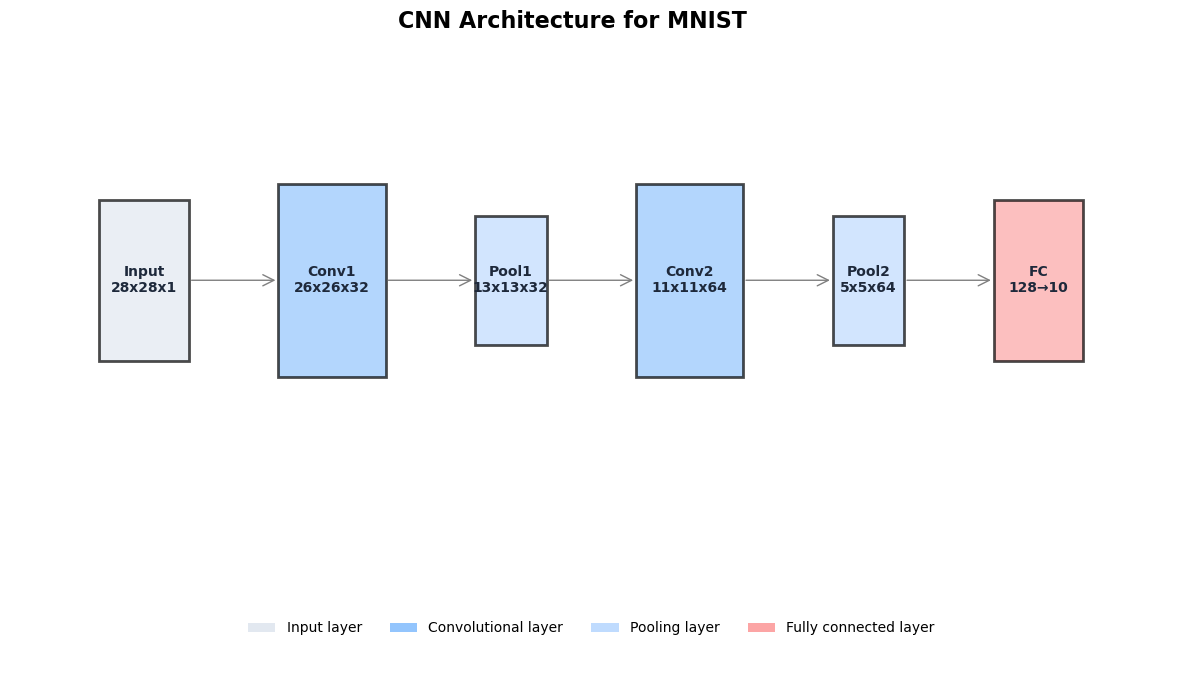

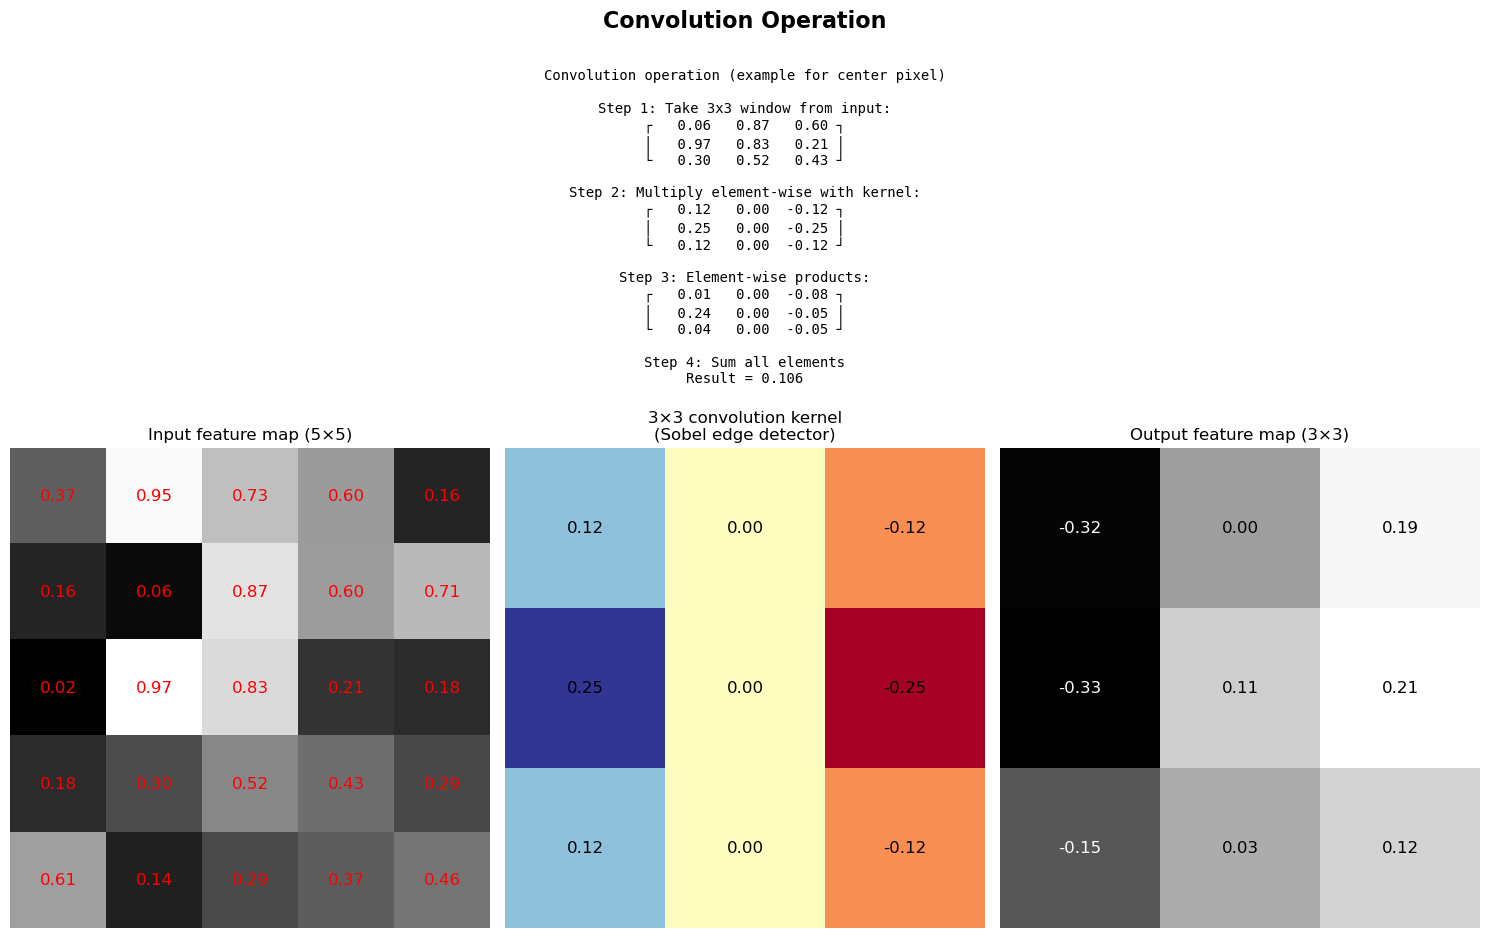

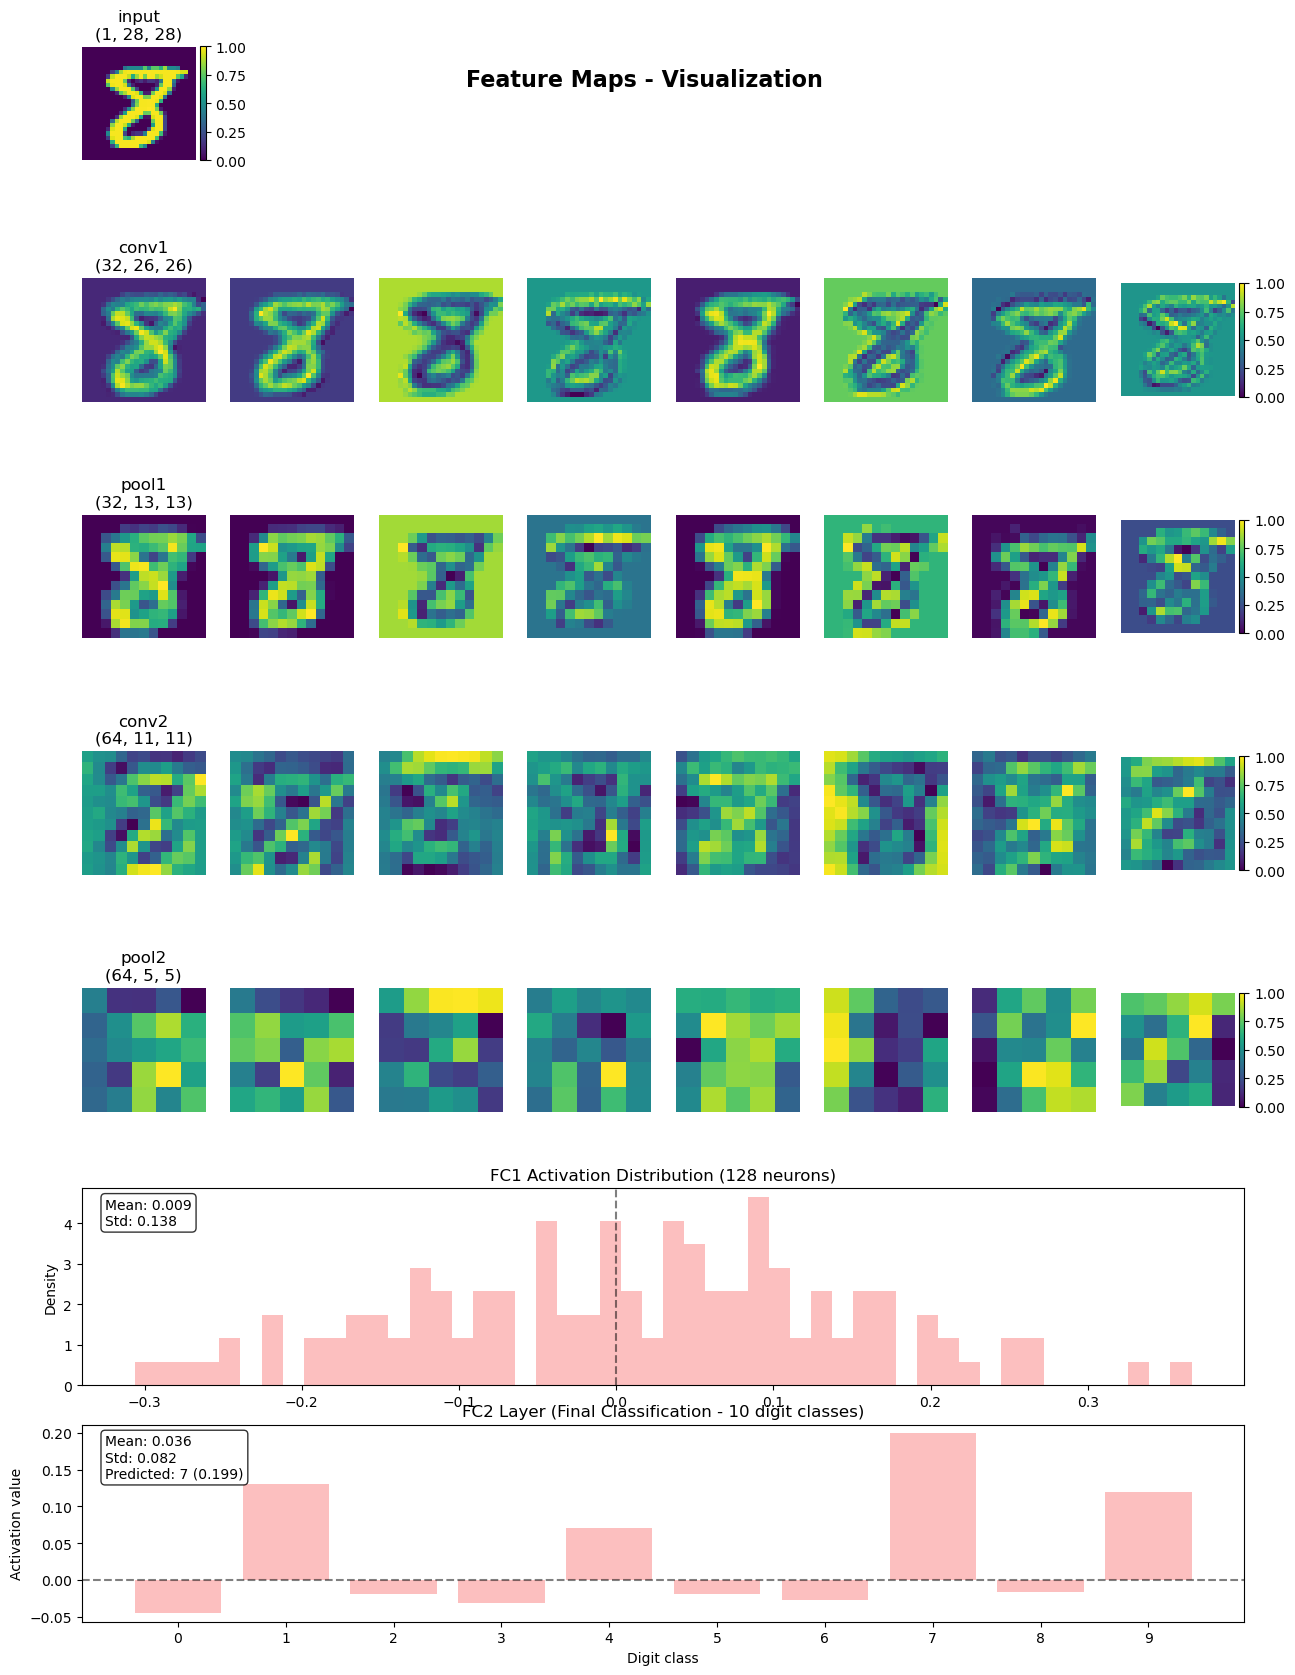

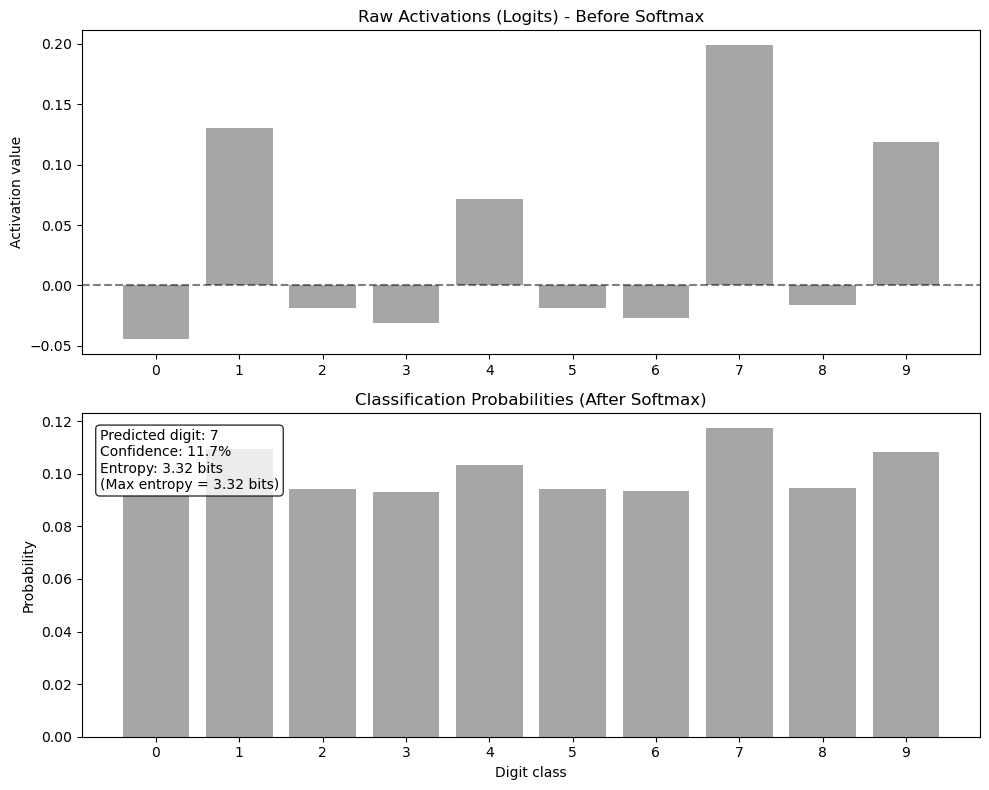


All visualizations complete!


In [67]:
# =============================================================================
# PART 3: RUN THE VISUALIZATIONS
# =============================================================================
# Now we put it all together: create the model, load an image, and visualize!

# === Step 1: Create the visualizer ===
visualizer = CNNVisualizer()
print("✓ Visualizer created")

# === Step 2: Draw and save the architecture diagram ===
# This shows the overall structure of our CNN
arch_fig = visualizer.draw_architecture(save_path='mnist_images/cnn_architecture.png')
print("✓ Architecture diagram saved to mnist_images/cnn_architecture.png")

# === Step 3: Visualize the convolution operation ===
# This shows step-by-step how convolution works
conv_fig = visualizer.visualize_convolution(save_path='mnist_images/convolution.png')
print("✓ Convolution visualization saved to mnist_images/convolution.png")

# === Step 4: Create the CNN model ===
# Set random seed for reproducible weight initialization
torch.manual_seed(42)
model = SimpleCNN()
print("✓ SimpleCNN model created with reproducible weights")

# === Step 5: Load a real MNIST image ===
# We use an actual digit image (not random noise) for meaningful visualization

if is_colab:
    # In Google Colab: download image from GitHub
    import requests
    import io
    from PIL import Image

    url = 'https://raw.githubusercontent.com/arvidl/BMED365-2026/main/Lab2-DL/data/mnist_image_0000.png'
    response = requests.get(url, stream=True).raw
    image = Image.open(response)
    img = np.array(image)
    print("✓ MNIST image loaded from GitHub (Colab)")
else:
    # Running locally: load from file system
    img_path = "../data/mnist_image_0000.png"
    img = plt.imread(img_path)
    print(f"✓ MNIST image loaded from {img_path}")

# === Step 6: Preprocess the image for the CNN ===
# Convert RGBA to grayscale if necessary (PNG files often have 4 channels)
if len(img.shape) == 3:
    img = img[:, :, 0]  # Take first channel only
    print(f"  - Converted from RGBA to grayscale")

# Convert numpy array to PyTorch tensor
# unsqueeze adds dimensions: (28, 28) → (1, 1, 28, 28)
#   First 1: batch size (we have 1 image)
#   Second 1: number of channels (grayscale = 1)
input_image = torch.from_numpy(img).float()
input_image = input_image.unsqueeze(0).unsqueeze(0)
print(f"  - Input tensor shape: {input_image.shape} (batch, channels, height, width)")

# === Step 7: Visualize feature maps ===
# This is the most insightful visualization - see what each layer "sees"
feature_fig = visualizer.visualize_feature_maps(
    model, input_image, save_path='mnist_images/feature_maps.png'
)
print("✓ Feature maps saved to mnist_images/feature_maps.png")

# === Display all visualizations ===
plt.show()

print("\n" + "="*60)
print("All visualizations complete!")
print("="*60)

### Detailed Convolution Calculations

The convolution operation shown above can be understood step-by-step. Here we show the calculations for two output pixels: the **upper left** (position [0,0]) and the **center** (position [1,1]).

#### Input Data (5×5)

Using `np.random.seed(42)` and `np.random.rand(5,5)`:

$$
\text{Input} = \begin{bmatrix}
0.37 & 0.95 & 0.73 & 0.60 & 0.16 \\
0.16 & 0.06 & 0.87 & 0.60 & 0.71 \\
0.02 & 0.97 & 0.83 & 0.21 & 0.18 \\
0.18 & 0.30 & 0.52 & 0.43 & 0.29 \\
0.61 & 0.14 & 0.29 & 0.37 & 0.46
\end{bmatrix}
$$

#### Kernel (3×3 Sobel-like edge detector)

$$
\text{Kernel} = \frac{1}{8}\begin{bmatrix}
1 & 0 & -1 \\
2 & 0 & -2 \\
1 & 0 & -1
\end{bmatrix} = \begin{bmatrix}
0.125 & 0.00 & -0.125 \\
0.25 & 0.00 & -0.25 \\
0.125 & 0.00 & -0.125
\end{bmatrix}
$$

---

#### Calculation for Upper Left Pixel: Output[0,0]

**Step 1:** Extract 3×3 window (rows 0-2, cols 0-2):

$$
\text{Window}_{[0,0]} = \begin{bmatrix}
0.37 & 0.95 & 0.73 \\
0.16 & 0.06 & 0.87 \\
0.02 & 0.97 & 0.83
\end{bmatrix}
$$

**Step 2:** Element-wise multiplication:

$$
\text{Products} = \begin{bmatrix}
0.37 \times 0.125 & 0.95 \times 0.00 & 0.73 \times (-0.125) \\
0.16 \times 0.25 & 0.06 \times 0.00 & 0.87 \times (-0.25) \\
0.02 \times 0.125 & 0.97 \times 0.00 & 0.83 \times (-0.125)
\end{bmatrix} = \begin{bmatrix}
0.047 & 0.00 & -0.091 \\
0.039 & 0.00 & -0.217 \\
0.003 & 0.00 & -0.104
\end{bmatrix}
$$

**Step 3:** Sum all elements:

$$
\text{Output}[0,0] = (0.047 + 0.039 + 0.003) + (-0.091 - 0.217 - 0.104) = 0.089 - 0.412 = \boxed{-0.32}
$$

> **Interpretation:** The negative value indicates the right side of this window is brighter than the left — this Sobel kernel detects vertical edges.

---

#### Calculation for Center Pixel: Output[1,1]

**Step 1:** Extract 3×3 window (rows 1-3, cols 1-3):

$$
\text{Window}_{[1,1]} = \begin{bmatrix}
0.06 & 0.87 & 0.60 \\
0.97 & 0.83 & 0.21 \\
0.30 & 0.52 & 0.43
\end{bmatrix}
$$

**Step 2:** Element-wise multiplication:

$$
\text{Products} = \begin{bmatrix}
0.06 \times 0.125 & 0.87 \times 0.00 & 0.60 \times (-0.125) \\
0.97 \times 0.25 & 0.83 \times 0.00 & 0.21 \times (-0.25) \\
0.30 \times 0.125 & 0.52 \times 0.00 & 0.43 \times (-0.125)
\end{bmatrix} = \begin{bmatrix}
0.007 & 0.00 & -0.075 \\
0.242 & 0.00 & -0.053 \\
0.038 & 0.00 & -0.054
\end{bmatrix}
$$

**Step 3:** Sum all elements:

$$
\text{Output}[1,1] = (0.007 + 0.242 + 0.038) + (-0.075 - 0.053 - 0.054) = 0.287 - 0.182 = \boxed{0.11}
$$

> **Interpretation:** The small positive value indicates the left side of this window is slightly brighter than the right — a weak edge in the opposite direction.

---

#### Summary Table

| Output Position | Window Location | Result | Interpretation |
|-----------------|-----------------|--------|----------------|
| [0,0] (upper left) | rows 0-2, cols 0-2 | -0.32 | Strong right-to-left gradient |
| [1,1] (center) | rows 1-3, cols 1-3 | 0.11 | Weak left-to-right gradient |

### ✅ Check Your Understanding: Convolution

Test your understanding of convolution with these questions:

**Q1:** If we have a 10×10 input and apply a 3×3 kernel (no padding), what is the output size?

<details>
<summary>Click for answer</summary>

**Answer:** 8×8

Formula: output = input - kernel + 1 = 10 - 3 + 1 = 8

We lose 1 pixel on each edge.
</details>

**Q2:** Why do we use 32 different filters in Conv1 instead of just 1?

<details>
<summary>Click for answer</summary>

**Answer:** Each filter learns to detect a different pattern (horizontal edges, vertical edges, corners, etc.). Using 32 filters means we can detect 32 different types of features simultaneously. It's like using 32 different staining techniques in histology.
</details>

**Q3:** What happens to the number of "channels" as we go deeper into the network?

<details>
<summary>Click for answer</summary>

**Answer:** The number of channels typically **increases** (1 → 32 → 64), while the spatial dimensions **decrease** (28 → 13 → 5). This is intentional: we trade spatial resolution for more abstract feature representations.
</details>

> 💡 **Tip:** If you can answer these questions, you understand the core concepts of convolution!

### Understanding the Feature Map Visualization

The visualization shows how the input image is transformed as it passes through different layers in the convolutional neural network (CNN). Let's go through each layer:

#### Input Layer
- Shows the original 28×28 grayscale image
- Single channel input (shape: 1×28×28)
- Uses a real MNIST digit image (mnist_image_0000.png)
- Displays the raw pixel intensities before any processing

#### Conv1 Layer
- First convolutional layer with 32 filters
- Output shape: 26×26×32 (reduced from 28×28 due to 3×3 kernel without padding)
- Each feature map shows different patterns/features learned by individual filters
- Some filters may activate on edges, others on textures or specific patterns

#### Pool1 Layer
- First max pooling layer (2×2 window with stride 2)
- Output shape: 13×13×32 (halved dimensions from Conv1)
- Preserves important features while reducing spatial dimensions
- Helps achieve spatial invariance and reduces computation

#### Conv2 Layer
- Second convolutional layer with 64 filters
- Output shape: 11×11×64
- Learns more complex features by combining patterns from Pool1
- Higher-level features compared to Conv1 (more abstract patterns)

#### Pool2 Layer
- Second max pooling layer
- Output shape: 5×5×64
- Further reduces spatial dimensions
- Maintains most important features for classification

#### FC1 Activation Distribution
- First fully connected layer (flattened Pool2 → 128 neurons)
- Shows histogram of activation values
- Mean and standard deviation indicate the spread of activations
- Distribution shape reveals how neurons are utilizing the activation space

#### FC2 Activation Distribution
- Final fully connected layer (128 → 10 neurons)
- Output corresponds to class probabilities (for MNIST digits 0-9)
- Distribution typically shows more distinct patterns as it's directly related to classification
- Mean and std values indicate the confidence and spread of predictions

The progression through these layers demonstrates how the network transforms from raw pixel data to increasingly abstract features, ultimately leading to classification outputs. The feature maps provide insights into what patterns each layer has learned to detect.


### The FC2 Layer: From Features to Diagnosis (Final Classification)

The FC2 layer is where the CNN makes its **final decision** — converting abstract features into a prediction. This is analogous to a physician integrating all findings into a diagnosis with confidence levels.

---

#### Step 1: Raw Activations (Logits)

The FC2 layer outputs 10 values, one for each digit class $k \in \{0, 1, 2, ..., 9\}$:

$$
z_k = \sum_{j=1}^{128} w_{kj} \cdot h_j + b_k
$$

Where:
- $z_k$ = raw activation (logit) for class $k$
- $w_{kj}$ = learned weight connecting FC1 neuron $j$ to output $k$
- $h_j$ = activation from FC1 layer (128 neurons)
- $b_k$ = bias term for class $k$

**Key properties of logits:**
- Can be any real number: $z_k \in (-\infty, +\infty)$
- Higher value = more "evidence" for that class
- Not directly interpretable as probabilities

---

#### Step 2: Softmax Transformation (Logits → Probabilities)

To convert logits into probabilities, we apply the **softmax function**:

$$
P(y = k \mid x) = \frac{e^{z_k}}{\sum_{j=0}^{9} e^{z_j}}
$$

Where:
- $P(y = k \mid x)$ = probability that the input $x$ belongs to class $k$
- $e^{z_k}$ = exponential of the logit (makes all values positive)
- The denominator normalizes so probabilities sum to 1

**Why softmax?**

| Property | Mathematical guarantee | Interpretation |
|----------|------------------------|----------------|
| Non-negative | $e^{z_k} > 0$ always | No negative probabilities |
| Normalized | $\sum_{k=0}^{9} P(k) = 1$ | Valid probability distribution |
| Monotonic | If $z_a > z_b$ then $P(a) > P(b)$ | Ordering preserved |
| Differentiable | Smooth gradients | Enables training via backpropagation |

**Example calculation:**
If logits are $[z_0, z_1, ..., z_9] = [-1.2, 0.5, 3.1, -0.8, ...]$

$$
P(y=2) = \frac{e^{3.1}}{e^{-1.2} + e^{0.5} + e^{3.1} + e^{-0.8} + ...}
$$

The class with $z_k = 3.1$ will have the highest probability.

---

#### Step 3: Final Prediction (Argmax)

The predicted class is the one with maximum probability:

$$
\hat{y} = \arg\max_{k} P(y = k \mid x)
$$

In Python:
```python
predicted_digit = np.argmax(probabilities)  # Returns index of highest value
confidence = np.max(probabilities)          # The probability of that prediction
```

---

#### Step 4: Measuring Uncertainty (Entropy)

**Entropy** quantifies the uncertainty in the prediction:

$$
H = -\sum_{k=0}^{9} P(k) \log_2 P(k)
$$

| Entropy value | Interpretation | Clinical analogy |
|---------------|----------------|------------------|
| $H \approx 0$ | Very confident (one class dominates) | Clear diagnosis |
| $H \approx 1$ | Uncertain between 2 classes | Differential with 2 candidates |
| $H \approx 3.32$ | Maximum uncertainty (uniform distribution) | Completely unsure |

**Why entropy matters in medicine:**
- A confident wrong prediction is dangerous
- Entropy helps identify cases needing human review
- High entropy → request additional tests / imaging

---

#### Summary: The Complete Decision Pipeline

$$
\text{Image} \xrightarrow{\text{CNN layers}} \mathbf{h} \xrightarrow{\text{FC2}} \mathbf{z} \xrightarrow{\text{softmax}} \mathbf{P} \xrightarrow{\text{argmax}} \hat{y}
$$

| Stage | Symbol | Shape | Range | Meaning |
|-------|--------|-------|-------|---------|
| FC1 output | $\mathbf{h}$ | (128,) | $\mathbb{R}$ | Abstract features |
| Logits | $\mathbf{z}$ | (10,) | $(-\infty, +\infty)$ | Raw class scores |
| Probabilities | $\mathbf{P}$ | (10,) | $[0, 1]$, sum=1 | Confidence per class |
| Prediction | $\hat{y}$ | scalar | $\{0,...,9\}$ | Final diagnosis |

---

**Medical analogy:** The FC2 layer is like a radiologist's final report:
- Logits = internal reasoning ("strong evidence for tumor, weak for cyst")
- Probabilities = confidence levels ("85% tumor, 10% cyst, 5% other")
- Prediction = final diagnosis ("Most likely: tumor")
- Entropy = certainty ("High confidence" vs "Recommend biopsy")

---

#### Training vs. Inference: Two Different Roles

The FC2 layer behaves differently depending on whether the model is **learning** (training) or **predicting** (inference):

| Aspect | Training | Inference |
|--------|----------|-----------|
| **Goal** | Adjust weights to improve predictions | Make predictions on new data |
| **Uses softmax?** | Yes (for loss calculation) | Optional (argmax works on logits too) |
| **Computes loss?** | Yes | No |
| **Updates weights?** | Yes (via backpropagation) | No (weights are frozen) |

##### During Training: Learning from Mistakes

1. **Forward pass**: Compute logits $\mathbf{z}$ and probabilities $\mathbf{P}$

2. **Loss calculation**: Compare prediction to true label using **cross-entropy loss**:

$$
\mathcal{L} = -\log P(y = y_{\text{true}} \mid x) = -\log \frac{e^{z_{y_{\text{true}}}}}{\sum_j e^{z_j}}
$$

   - If true label is "7" and $P(y=7) = 0.85$, loss = $-\log(0.85) = 0.16$ (small)
   - If true label is "7" and $P(y=7) = 0.01$, loss = $-\log(0.01) = 4.6$ (large!)

3. **Backpropagation**: Compute gradients $\frac{\partial \mathcal{L}}{\partial w}$ for all weights

4. **Weight update**: Adjust weights to reduce loss:
$$
w_{\text{new}} = w_{\text{old}} - \eta \cdot \frac{\partial \mathcal{L}}{\partial w}
$$
   where $\eta$ is the learning rate

**Medical analogy**: Training is like a resident learning from cases:
- Makes a diagnosis (forward pass)
- Attending reveals correct answer (true label)
- Resident reflects on error (loss calculation)
- Updates mental model (weight update)

##### During Inference: Making Predictions

1. **Forward pass only**: Compute logits $\mathbf{z}$ (and optionally $\mathbf{P}$)

2. **Prediction**: 
$$
\hat{y} = \arg\max_k z_k
$$
   Note: We can skip softmax since $\arg\max$ is the same for logits and probabilities!

3. **No learning**: Weights remain fixed

**Medical analogy**: Inference is like a trained physician seeing patients:
- Applies learned knowledge
- Makes diagnosis with confidence
- No "grade" or feedback loop

##### Code Difference

```python
# === TRAINING MODE ===
model.train()                          # Enable training behavior
optimizer.zero_grad()                  # Clear previous gradients
outputs = model(images)                # Forward pass
loss = criterion(outputs, labels)      # Compute cross-entropy loss
loss.backward()                        # Backpropagation
optimizer.step()                       # Update weights

# === INFERENCE MODE ===
model.eval()                           # Disable training behavior
with torch.no_grad():                  # Don't track gradients (faster, less memory)
    outputs = model(images)            # Forward pass only
    _, predicted = torch.max(outputs, 1)  # Get predictions
```

##### Why This Matters in Medicine

| Training | Inference |
|----------|-----------|
| Requires labeled data (expensive in medicine) | Works on unlabeled new cases |
| Computationally intensive | Fast, can run on device |
| Happens once (or periodically) | Happens every time model is used |
| Done by AI developers | Done by clinicians/hospitals |



### ✅ Check Your Understanding: Classification

Test your understanding of the final classification layer:

**Q1:** Why can't we use logits directly as the final prediction confidence?

<details>
<summary>Click for answer</summary>

**Answer:** Logits can be any real number (positive or negative, any magnitude), so they can't be interpreted as probabilities. Softmax converts them to values between 0 and 1 that sum to 1, making them valid probabilities.
</details>

**Q2:** If the softmax output is [0.01, 0.01, 0.90, 0.02, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01], what digit does the model predict and with what confidence?

<details>
<summary>Click for answer</summary>

**Answer:** The model predicts digit **2** (index 2 has the highest probability) with **90% confidence**.

The entropy would be low (≈0.6 bits), indicating high certainty.
</details>

**Q3:** During inference, why can we skip the softmax and just use argmax on the logits?

<details>
<summary>Click for answer</summary>

**Answer:** Because argmax finds the maximum value, and softmax preserves the ordering (if logit A > logit B, then softmax(A) > softmax(B)). So argmax(logits) = argmax(softmax(logits)).

However, if we want the probability/confidence score, we still need softmax.
</details>

**Q4:** Why is entropy important in medical AI applications?

<details>
<summary>Click for answer</summary>

**Answer:** Entropy measures uncertainty. High entropy means the model is unsure, which is critical in medicine because:
- Uncertain predictions should trigger human review
- Overconfident wrong predictions are dangerous
- High uncertainty cases might need additional tests/imaging
</details>

> 🏥 **Clinical Connection:** In medical AI, we often set a threshold (e.g., "flag for review if confidence < 95% or entropy > 0.5") to ensure uncertain cases receive human attention.

---

## 📚 Glossary of Key Terms

| Term | Definition | Medical Analogy |
|------|------------|-----------------|
| **Activation** | Output of a neuron after applying a function | Signal strength of a finding |
| **Backpropagation** | Algorithm to compute gradients for training | Learning from mistakes |
| **Batch** | Group of samples processed together | Multiple patients in a study |
| **Channel** | Depth dimension of feature maps (e.g., 32 filters = 32 channels) | Different staining techniques |
| **Convolution** | Sliding a filter over an image to detect patterns | Scanning tissue with a microscope |
| **Cross-entropy loss** | Loss function for classification tasks | Measure of diagnostic error |
| **Epoch** | One complete pass through all training data | One round of studying all cases |
| **Feature map** | Output of a convolutional layer | Highlighted structures after staining |
| **Filter/Kernel** | Small learnable matrix (e.g., 3×3) that detects patterns | A specific stain for specific structures |
| **Flatten** | Reshape 2D/3D data into 1D vector | Summarizing all spatial findings |
| **Forward pass** | Data flowing through network to get prediction | Examination → Diagnosis |
| **Fully connected (FC)** | Layer where every input connects to every output | Integrating all findings |
| **Gradient** | Direction and magnitude of weight change needed | How much to adjust understanding |
| **Inference** | Using trained model to make predictions | Applying learned knowledge to new cases |
| **Kernel size** | Dimensions of the convolutional filter (e.g., 3×3) | Size of microscope field of view |
| **Learning rate** | How much to update weights each step | Speed of learning |
| **Logits** | Raw output scores before softmax | Informal confidence before calibration |
| **Max pooling** | Taking maximum value in a window | Keeping most prominent finding |
| **Neuron** | Basic computational unit in a network | A decision-making cell |
| **Padding** | Adding zeros around image borders | Extending the slide edges |
| **Parameters** | Learnable weights and biases | Doctor's learned knowledge |
| **ReLU** | Activation function: max(0, x) | Ignoring negative evidence |
| **Softmax** | Converts logits to probabilities summing to 1 | Formalizing confidence as percentages |
| **Stride** | Step size when sliding filter | How far to move between observations |
| **Tensor** | Multi-dimensional array (generalization of matrix) | Data structure for images |
| **Training** | Process of learning weights from data | Medical education/residency |
| **Weights** | Learnable parameters in a layer | Stored knowledge |

---

## 🎯 Summary: Key Takeaways

### The Big Picture

```
┌─────────────────────────────────────────────────────────────────────────────────────┐
│                     CNN: From Pixels to Prediction                                  │
├─────────────────────────────────────────────────────────────────────────────────────┤
│                                                                                     │
│  Image      →  Conv+Pool  →  Conv+Pool  →  Flatten  →  FC  →  Softmax               │
│  (28×28)       (detect       (detect       (1D         (combine)  (probabilities)   │
│                 edges)        shapes)       vector)                                 │
│                                                                                     │
│  Raw data  →  Low-level  →  High-level →  Abstract →  Decision → Diagnosis          │
│                features      features      features                                 │
└─────────────────────────────────────────────────────────────────────────────────────┘
```

### Core Concepts

| # | Concept | Key Insight | Remember This |
|---|---------|-------------|---------------|
| 1 | **CNNs exploit spatial structure** | Nearby pixels are related | Unlike regular NNs, CNNs understand images |
| 2 | **Convolution = pattern detection** | Small filters slide across image | Output shrinks: size - kernel + 1 |
| 3 | **Filters are learned, not designed** | Network discovers useful patterns | Training finds edge detectors, etc. |
| 4 | **Pooling = robust summarization** | Keeps important info, reduces size | Adds translation invariance |
| 5 | **Deeper = more abstract** | Early layers: edges; Later: concepts | Hierarchical feature learning |
| 6 | **FC layers = decision making** | Combine all features for classification | Like integrating clinical findings |
| 7 | **Softmax = calibrated confidence** | Logits → Probabilities (sum to 1) | Enables uncertainty quantification |
| 8 | **Training ≠ Inference** | Training updates weights; Inference uses them | Different computational requirements |

### Medical AI Connection

| MNIST Concept | Medical Imaging Application |
|---------------|----------------------------|
| Digit classification (10 classes) | Lesion classification (benign/malignant) |
| 28×28 grayscale image | CT slice, X-ray, histology patch |
| Learned filters | Texture, shape, boundary detectors |
| Softmax probabilities | Differential diagnosis with confidence |
| Entropy/uncertainty | Cases needing expert review |
| Feature maps | Explainability: what did the AI see? |

### What You Can Now Explain

After completing this notebook, you should be able to answer:

- ✅ "What is a CNN and why is it good for images?"
- ✅ "How does convolution work and why does the image shrink?"
- ✅ "What do the layers of a CNN actually learn?"
- ✅ "How does a CNN make its final prediction?"
- ✅ "What's the difference between logits and probabilities?"
- ✅ "Why is uncertainty important in medical AI?"

---

## 🚀 What's Next?

This notebook introduced CNN concepts through visualization. In the following notebooks and labs, we will:

| Next Step | What You'll Learn |
|-----------|-------------------|
| **Train a CNN** | How to actually train this model on MNIST data |
| **Evaluate performance** | Accuracy, confusion matrix, precision/recall |
| **Data augmentation** | Techniques to improve model robustness |
| **Transfer learning** | Using pre-trained models for new tasks |
| **Medical imaging** | Apply CNNs to X-rays, CT scans, histopathology |
| **Model interpretation** | Grad-CAM, saliency maps, explainable AI |

---

## 📖 Further Reading & Resources

### Video Tutorials (Highly Recommended)

| Resource | Description | Link |
|----------|-------------|------|
| **3Blue1Brown: Neural Networks** | Beautiful visual explanations of neural networks | [YouTube Playlist](https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi) |
| **StatQuest: Neural Networks** | Step-by-step explanations with simple examples | [YouTube Channel](https://www.youtube.com/c/joshstarmer) |

### Courses & Textbooks

| Resource | Description |
|----------|-------------|
| **Stanford CS231n** | Comprehensive CNN course (free lecture notes & videos) |
| **Fast.ai Practical Deep Learning** | Hands-on, top-down approach to deep learning |
| **Deep Learning Book** (Goodfellow et al.) | The "bible" of deep learning theory |

### Medical AI Specific

| Resource | Description |
|----------|-------------|
| **MONAI** | PyTorch-based framework for medical imaging AI |
| **fastMONAI** | High-level API for medical imaging deep learning |
| **Grand Challenge** | Platform for medical imaging AI challenges |
| **Radiopaedia** | Great resource for understanding medical images |

### Papers for the Curious

| Paper | Why It's Important |
|-------|-------------------|
| LeCun et al. (1998) - LeNet | The original CNN paper that started it all |
| Krizhevsky et al. (2012) - AlexNet | The paper that sparked the deep learning revolution |
| He et al. (2016) - ResNet | Introduced skip connections, enabling very deep networks |
| Rajpurkar et al. (2017) - CheXNet | CNN matching radiologist performance on chest X-rays |

---

## 🙏 Acknowledgments

This notebook was created for BMED365 at the University of Bergen. The visualizations and explanations are designed to help medical students understand deep learning concepts through familiar clinical analogies.

---

*Last updated: 2026-01-15*